In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig
from tqdm import tqdm
from scipy.stats import spearmanr,mannwhitneyu
import ruptures as rpt
from sklearn.preprocessing import StandardScaler
import hdbscan
import networkx as nx
from scipy.cluster.hierarchy import linkage, dendrogram


In [ ]:
# set working directory to files
WD = #confidential
# Change ID15 for other patients

ID = 'ID15'
MI = 'mutual_informations_per_link.npz'
onset_window=700
dt=0.25 
M=3 #for topM-topK (I have choosen this value after having tested different values of M)
fractions=np.linspace(0,1,20) #for GCC robustness analysis

#dynamic windowing (over MI time axis)
window_size=20 #12.5s 
step=5 #25% overlapping 

#monte Carlo for random failures
n_repeats_static=20
n_repeats_dynamic=10


In [178]:

# Load whatever information 
def load_data( wd:str, patient_id:str, data_name:str):
    out = np.load( wd + patient_id + "/" + data_name)['data']
    return out

node_ids=load_data(WD,ID,"node_ids.npz") 
mi_80=load_data(WD,ID,"mutual_informations_per_link_80cut.npz")  
mi_full = load_data(WD, ID, "mutual_informations_per_link.npz")
links_ids = load_data(WD, ID, 'link_ids.npz').astype(int) 

N=len(node_ids)
L,W=mi_full.shape


print(f" Fraction of zero MI values : {np.mean(mi_full==0):.3f}") 



 Fraction of zero MI values : 0.000


In [179]:
def select_edges_topM_topK(link_ids, weights, n_nodes, M):
    """
    Hybrid thresholding 
    For each time frame, we retain:
    - the M strongest connections incident to each node
    - the K = N * M strongest connections globally

    An edge is kept if it satisfies at least one of the two criteria.
    This step is used to control graph connectivity and allow
    structural comparability across time windows.
    """

    # Total number of possible links in the dataset
    L = link_ids.shape[0]

    # Total number of edges allowed by the global criterion
    K = n_nodes * M

    # Boolean mask that will mark which edges survive the thresholding
    mask = np.zeros(L, dtype=bool)

    active = weights > 0
    idx_active = np.where(active)[0]

    # First, we apply a global criterion by keeping the K strongest
    # edges across the entire network
    w_active = weights[idx_active]

    if len(w_active) > K:
        topk = idx_active[np.argpartition(w_active, -K)[-K:]]
    else:
        # If fewer than K active edges exist, we keep all of them
        topk = idx_active
    mask[topk] = True

    # In parallel, we enforce a local criterion by making sure that
    # each node keeps at least its M strongest incident connections
    edges_per_node = [[] for _ in range(n_nodes)]
    for el in idx_active:
        u, v = link_ids[el]
        # Each edge contributes to the connectivity of both endpoints
        edges_per_node[u].append((weights[el], el))
        edges_per_node[v].append((weights[el], el))

    # For every node, we now select its top-M strongest edges
    for u in range(n_nodes):
        if len(edges_per_node[u]) == 0:
            # The node has no active connections at this time
            continue
        edges = edges_per_node[u]
        if len(edges) <= M:
            # If the node has fewer than M edges, we keep all of them
            for _, el in edges:
                mask[el] = True
        else:
            # Otherwise, we keep only the M strongest ones
            w = np.array([x[0] for x in edges])
            eidx = np.array([x[1] for x in edges])

            topm = np.argpartition(w, -M)[-M:]
            mask[eidx[topm]] = True

    return mask


In [180]:
def build_weighted_graph(node_ids, link_ids, weights, edge_mask):
    """
    Builds a weighted undirected igraph graph for a single time frame.
    """
    n_nodes = len(node_ids)
    G = ig.Graph()
    G.add_vertices(n_nodes)

    edges = []
    edge_weights = []

    for (u, v), w in zip(link_ids[edge_mask], weights[edge_mask]):
        if w > 0:
            edges.append((int(u), int(v)))
            edge_weights.append(float(w))

    if len(edges) > 0:
        G.add_edges(edges)
        G.es["weight"] = edge_weights

    return G


In [181]:
w_pre=mi_full[:,:onset_window].mean(axis=1)
w_ict=mi_full[:,onset_window:].mean(axis=1)
mask_pre=select_edges_topM_topK(links_ids,w_pre,N,M=M)
mask_ict=select_edges_topM_topK(links_ids,w_ict,N,M=M) 

G_pre=build_weighted_graph(node_ids,links_ids,w_pre,mask_pre)
G_ict=build_weighted_graph(node_ids,links_ids,w_ict,mask_ict)
print(G_pre.ecount(), G_ict.ecount())
print(G_pre.components().giant().vcount(),
      G_ict.components().giant().vcount())


785 746
173 173


In [182]:
T = mi_full.shape[1]  # total number of temporal frame
windows = range(0, T - window_size + 1, step)


In [183]:
dynamic_igraphs_full = []

for t0 in windows:
    
    w_window = mi_full[:, t0:t0 + window_size].mean(axis=1)

    
    edge_mask = select_edges_topM_topK(
        link_ids=links_ids,
        weights=w_window,
        n_nodes=N,
        M=M
    )

    
    G = build_weighted_graph(
        node_ids=node_ids,
        link_ids=links_ids,
        weights=w_window,
        edge_mask=edge_mask
    )

    dynamic_igraphs_full.append(G)


In [184]:
def ncut_n1cut_from_igraph(G):
    n = G.vcount()
    if G.ecount() == 0:
        return np.nan, np.nan, np.zeros(n, dtype=int)

    W = np.zeros((n, n), dtype=float)
    edges = G.get_edgelist()
    weights = np.array(G.es["weight"], dtype=float)

    for (u, v), w in zip(edges, weights):
        W[u, v] += w
        W[v, u] += w

    d = W.sum(axis=1)
    eps = 1e-12
    d = np.maximum(d, eps)
    
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
    L_sym = D_inv_sqrt @ (np.diag(d) - W) @ D_inv_sqrt

    evals, evecs = np.linalg.eigh(L_sym)
    if len(evals) < 2:
        return np.nan, np.nan, np.zeros(n, dtype=int)

    fiedler = evecs[:, 1]

    
    if fiedler[d.argmax()] < 0:
        fiedler = -fiedler

    labels = (fiedler > 0).astype(int)
    if labels.sum() == 0 or labels.sum() == len(labels):
        labels = (fiedler > np.median(fiedler)).astype(int)

    A = labels == 0
    B = labels == 1

    cut = W[np.ix_(A, B)].sum()
    volA = d[A].sum()
    volB = d[B].sum()

    if volA == 0 or volB == 0:
        return np.nan, np.nan, labels

    ncut = cut/volA + cut/volB
    n1cut = cut / min(volA, volB)   

    return ncut, n1cut, labels

In [185]:
type_my='Sliding window and pairwise'

In [ ]:
def dynamic_n1cut(graphs):
    n1_series = []

    for G in tqdm(graphs, desc="Dynamic N1cut"):
        if G.ecount() == 0:
            n1_series.append(np.nan)
            continue

        _, n1cut, _ = ncut_n1cut_from_igraph(G)
        n1_series.append(n1cut)

    return np.array(n1_series)

n1_series = dynamic_n1cut(dynamic_igraphs_full)
onset_dyn = int(np.floor((onset_window - window_size) / step))

print("mean pre:", np.nanmean(n1_series[:onset_dyn]),
      "mean ictal:", np.nanmean(n1_series[onset_dyn:]))
print(
    "median pre:", np.nanmedian(n1_series[:onset_dyn]),
    "median ictal:", np.nanmedian(n1_series[onset_dyn:])
)

Dynamic N1cut:  28%|██▊       | 44/156 [00:08<00:22,  4.89it/s]

In [ ]:
print(F'{type_my} mean to MACHINE LEARING FOR {ID}')
print(n1_series)
print('###########')
print(n1_series.shape)

Sliding window and pairwise mean to MACHINE LEARING FOR ID15
[0.55586535 0.08172275 0.07906417 0.24334413 0.42052367 0.57068548
 0.36503028 0.25835994 0.17486065 0.25083589 0.20820082 0.26022983
 0.50031749 0.26808614 0.27142396 0.26658066 0.18022279 0.24168716
 0.23639003 0.20376354 0.24547595 0.21887626 0.24344808 0.23244218
 0.24695515 0.50144735 0.52558837 0.40726724 0.49896701 0.39430455
 0.30352011 0.37937598 0.34924203 0.21582213 0.16922066 0.12735527
 0.16320681 0.275178   0.29097882 0.38298342 0.34721558 0.35647392
 0.23740737 0.23394409 0.31106851 0.24534968 0.17872029 0.20261068
 0.35754568 0.32114234 0.21337864 0.32843631 0.25195276 0.32257007
 0.26206643 0.20955588 0.14153372 0.2441092  0.23898201 0.24118579
 0.28116852 0.23934418 0.36609769 0.37922875 0.40668401 0.55143924
 0.1762662  0.19585942 0.26397445 0.16499591 0.20636213 0.21395721
 0.26758783 0.1911376  0.30337497 0.26079675 0.24494447 0.25533828
 0.31922008 0.51991144 0.49646174 0.28509595 0.26137078 0.34576039
 

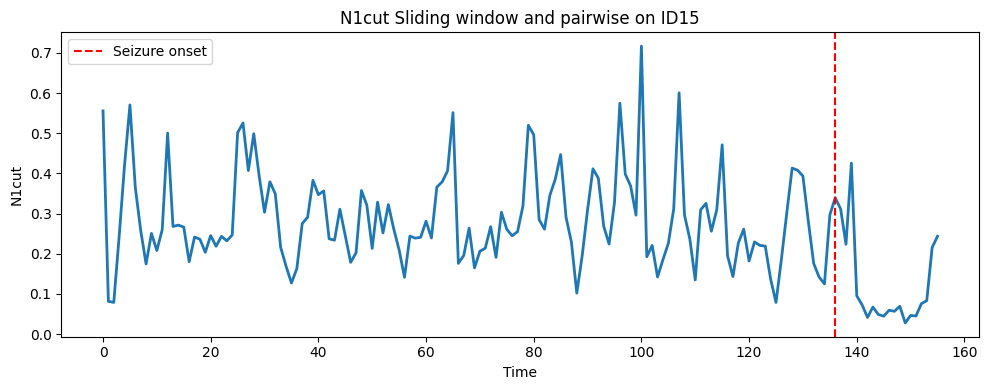

In [ ]:
def plot_n1cut(n1_series, ID, type_my, onset):
    plt.figure(figsize=(10,4))
    plt.plot(n1_series, lw=2)
    plt.axvline(onset, color='r', ls='--', label='Seizure onset')
    plt.ylabel("N1cut")
    plt.xlabel("Time")
    plt.title(f"N1cut {type_my} on {ID}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_n1cut(n1_series, ID, type_my,onset_dyn)
#onset_dyn ≈ (700 - 20) / 5 ≈ 136
#The born onset occurs at frame 700 of the mutual information time series, 
# the N1cut dynamics are defined over overlapping temporal windows; 
# for this reason, the onset corresponds to window index 136 in the reduced temporal representation.


# Pairwise dynamic approach based on sliding windows for n1cut

In [ ]:
times_abs = []        
phase_labels = []    # pre / ictal
n1_values = []       # N1cut(t)
n1_diff_1 = []       # |N1cut(t) - N1cut(t-1)|
edge_counts = []
avg_strengths = []
avg_weights = []


In [ ]:

for t0 in range(0, W - window_size + 1, step):

    t1 = t0 + window_size
    center = 0.5 * (t0 + t1)
    t_abs = center * dt
    phase = "pre_ictal" if center < onset_window else "ictal"

    # build graph
    w_block = mi_full[:, t0:t1].mean(axis=1)
    mask = select_edges_topM_topK(links_ids, w_block, N, M)
    G = build_weighted_graph(node_ids, links_ids, w_block, mask)

    # N1cut
    _, n1, _ = ncut_n1cut_from_igraph(G)
    n1_values.append(n1)

    # pairwise difference
    if len(n1_values) > 1:
        n1_diff_1.append(abs(n1_values[-1] - n1_values[-2]))
    else:
        n1_diff_1.append(np.nan)

   
    edge_counts.append(G.ecount())
    avg_strengths.append(np.mean(G.strength(weights="weight")))
    avg_weights.append(np.mean(G.es["weight"]) if G.ecount() > 0 else 0.0)

    times_abs.append(t_abs)
    phase_labels.append(phase)


In [ ]:
times_abs = np.array(times_abs)
phase_labels = np.array(phase_labels)

n1_values = np.array(n1_values)
n1_diff_1 = np.array(n1_diff_1)

edge_counts = np.array(edge_counts)
avg_strengths = np.array(avg_strengths)
avg_weights = np.array(avg_weights)

pre_mask = (phase_labels == "pre_ictal")
ict_mask = (phase_labels == "ictal")


In [ ]:
def plot_n1cut_level_heatmap(n1_values, t_abs, onset_s, ID, type_my):
    plt.figure(figsize=(10, 4))
    plt.imshow(
        n1_values[:, None],
        aspect="auto",
        origin="lower",
        extent=[0, 1, t_abs[0], t_abs[-1]],
        cmap="plasma",
        vmin=np.nanmin(n1_values),   
        vmax=np.nanmax(n1_values)   
    )
    plt.colorbar(label="N1cut")
    plt.axhline(onset_s, ls="--", c="k", alpha=0.8)
    plt.title(f"Dynamic N1cut (level) of {ID} with {type_my}")
    plt.ylabel("Time (s)")
    plt.tight_layout()
    plt.show()


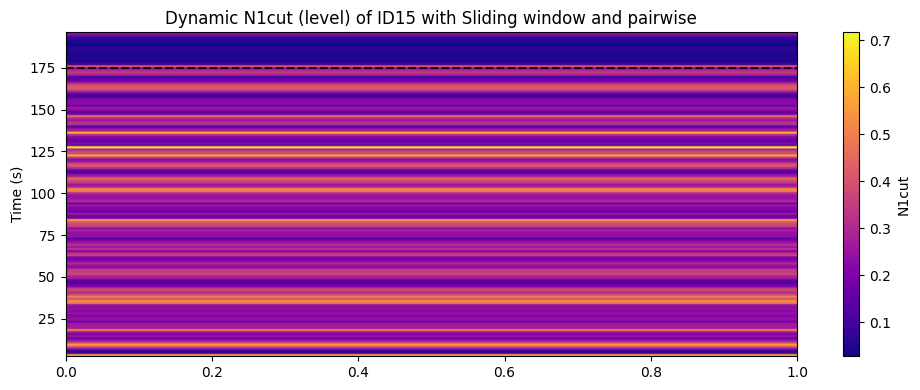

In [ ]:
onset_s = onset_window * dt

plot_n1cut_level_heatmap(
    n1_values,
    times_abs,
    onset_s,
    ID,
    type_my
)


In [ ]:

n1_delta = np.abs(np.diff(n1_values)) # absolut variation between consecutive windows


times_abs_delta = times_abs[1:] #to allinate labes
phase_labels_delta = phase_labels[1:]

pre_mask_d = phase_labels_delta == "pre_ictal"
ict_mask_d = phase_labels_delta == "ictal"


In [ ]:
print("N1cut temporal instability")
print(f"Mean |delta N1cut| pre-ictal : {np.nanmean(n1_delta[pre_mask_d]):.4f}")
print(f"Mean |delta N1cut| ictal     : {np.nanmean(n1_delta[ict_mask_d]):.4f}")

print(f"Median |delta N1cut| pre-ictal : {np.nanmedian(n1_delta[pre_mask_d]):.4f}")
print(f"Median |delta N1cut| ictal     : {np.nanmedian(n1_delta[ict_mask_d]):.4f}")


N1cut temporal instability
Mean |delta N1cut| pre-ictal : 0.0903
Mean |delta N1cut| ictal     : 0.0562
Median |delta N1cut| pre-ictal : 0.0680
Median |delta N1cut| ictal     : 0.0243


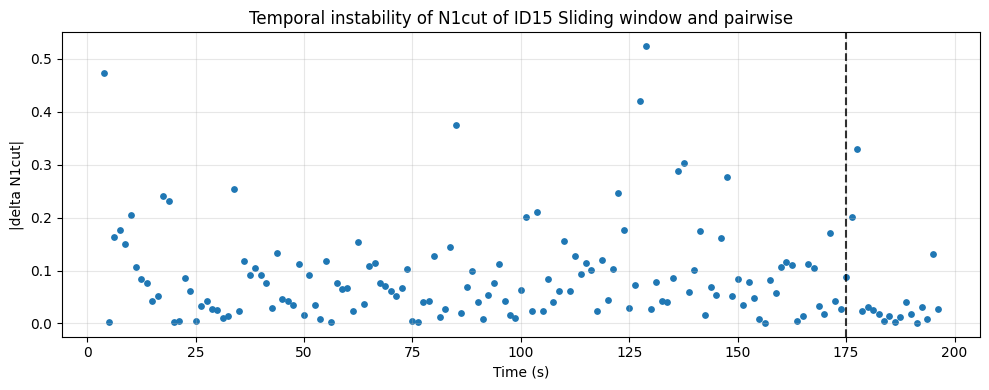

In [ ]:
def plot_temporal_instability(times_abs_delta, n1_delta, ID, type_my):
    plt.figure(figsize=(10,4))
    plt.scatter(times_abs_delta, n1_delta, s=15)
    plt.axvline(onset_s, ls="--", c="k", alpha=0.8)
    plt.title(f"Temporal instability of N1cut of {ID} {type_my}")
    plt.xlabel("Time (s)")
    plt.ylabel("|delta N1cut|")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_temporal_instability(times_abs_delta, n1_delta,ID, type_my)


# Anticipation analysis

verificare se N1cut, come misura dello stato globale della rete, mostra cambiamenti sistematici prima dell’onset dell’ictus

In [ ]:
t_pre = times_abs[pre_mask]
n1_pre = n1_values[pre_mask]
# work with negative temporal for comoditiy
t_rel_pre = t_pre - onset_s   # negativ time (before of onset)


In [ ]:
#smoothing 
#N1cut is noisy window by window 
#I need of a slow trend to see the Anticipation
def moving_average(x, w):
    return np.convolve(x, np.ones(w)/w, mode="valid")

w = 5  #try with 3–7
n1_pre_smooth = moving_average(n1_pre, w)
t_rel_pre_smooth = t_rel_pre[w-1:]


In [ ]:
rho, pval = spearmanr(t_rel_pre_smooth, n1_pre_smooth)
print(f"Spearman rho = {rho:.3f}, p = {pval:.4f}")
# i need to use Spearman beacuse dosent' assume linearity


Spearman rho = -0.102, p = 0.2418


In [ ]:
if pval > 0.05:
    print(f'for patient {ID} the anticipation analysis performed on pre-ictal N1cut values did not reveal a significant monotonic trend toward seizure onset')
else: print(f'for patient {ID} the anticipation analysis performed on pre-ictal N1cut values REVEAL a significant monotonic trend toward seizure onset')

for patient ID15 the anticipation analysis performed on pre-ictal N1cut values did not reveal a significant monotonic trend toward seizure onset


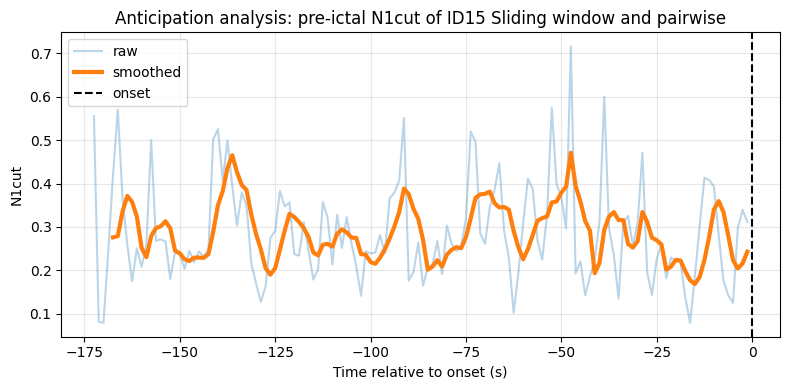

In [ ]:
plt.figure(figsize=(8,4))   

plt.plot(t_rel_pre, n1_pre, alpha=0.3, label="raw")
plt.plot(t_rel_pre_smooth, n1_pre_smooth, lw=3, label="smoothed")

plt.axvline(0, ls="--", c="k", label="onset")

plt.xlabel("Time relative to onset (s)")
plt.ylabel("N1cut")
plt.title(f"Anticipation analysis: pre-ictal N1cut of {ID} {type_my}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Chancing point verification

In [ ]:
signal = n1_pre_smooth
algo = rpt.Pelt(model="rbf").fit(signal)
bkpts = algo.predict(pen=5)

print("Change points (indices):", bkpts)
print("Change points (seconds):", t_rel_pre_smooth[bkpts[:-1]])


Change points (indices): [134]
Change points (seconds): []


# Directional anticipation

In [ ]:
#asimmetria prima/dopo onset
post_mask = (times_abs > onset_s) & (times_abs < onset_s + 30)

print("Mean |ΔN1cut| pre :", np.mean(n1_delta[pre_mask_d]))
print("Mean |ΔN1cut| early ictal :", np.mean(n1_delta[post_mask[1:]]))


Mean |ΔN1cut| pre : 0.09033466715439126
Mean |ΔN1cut| early ictal : 0.05434986485491151


If cahotic ictus i ascpet |ΔN1cut| ictal >> |ΔN1cut| pre



# Phase-specific distribution analysis

In [ ]:
n1_pre = n1_values[pre_mask]
n1_ict = n1_values[ict_mask]
print(len(n1_pre), len(n1_ict))



138 18


Boxplot to do a confront

/tmp/ipykernel_120294/3819139041.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([n1_pre, n1_ict], labels=["Pre-ictal", "Ictal"], showfliers=True)


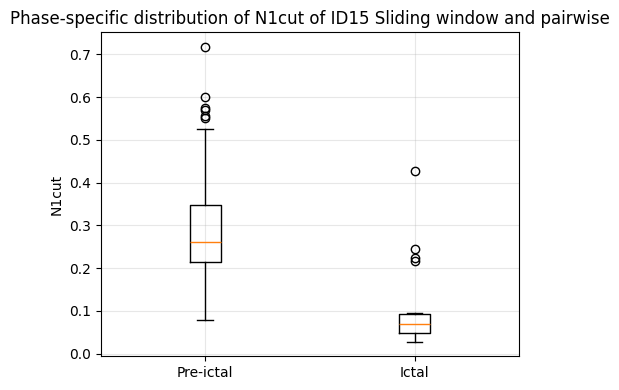

In [ ]:
plt.figure(figsize=(5,4))
plt.boxplot([n1_pre, n1_ict], labels=["Pre-ictal", "Ictal"], showfliers=True)
plt.ylabel("N1cut")
plt.title(f"Phase-specific distribution of N1cut of {ID} {type_my}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
def summarize_dist(x):
    return {
        "mean": np.mean(x),
        "median": np.median(x),
        "std": np.std(x),
        "iqr": np.percentile(x, 75) - np.percentile(x, 25)
    }

print("Pre-ictal:", summarize_dist(n1_pre))
print("Ictal   :", summarize_dist(n1_ict))


Pre-ictal: {'mean': np.float64(0.28752111009448417), 'median': np.float64(0.26138050315560635), 'std': np.float64(0.1149225480630737), 'iqr': np.float64(0.13242834672430587)}
Ictal   : {'mean': np.float64(0.1080823715107818), 'median': np.float64(0.06846635952910954), 'std': np.float64(0.10043582381910071), 'iqr': np.float64(0.0453411932156862)}


In [ ]:
U, p = mannwhitneyu(n1_pre, n1_ict, alternative="two-sided")#Recurrence quantification analysis of dynamic brain networks
 #the distribution are different?
print(f"Mann–Whitney U test: p = {p:.4e}")


Mann–Whitney U test: p = 5.3605e-08


# Entropy 

In [ ]:

#mask for entroby, otw give me errors for different size
window=10
pre_mask_ent = pre_mask[window-1:]
ict_mask_ent = ict_mask[window-1:]




In [ ]:
def shannon_entropy(x, n_bins=10):  #Time-resolved resting-state brain networks Zalesky et al., 2014
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan

    hist, _ = np.histogram(x, bins=n_bins, density=False)
    p = hist / hist.sum()
    p = p[p > 0]

    return -np.sum(p * np.log(p))

In [ ]:
def dynamic_entropy(series, window):
    ent = []
    for i in range(len(series) - window + 1):
        ent.append(shannon_entropy(series[i:i+window]))
    return np.array(ent)


In [ ]:
ent_n1 = dynamic_entropy(n1_series, window=10)

In [ ]:

print(f"mean pre_mask_ent: {np.nanmean(ent_n1[pre_mask_ent])}")
print(f"mean post_mask_ent: {np.nanmean(ent_n1[ict_mask_ent])}")


mean pre_mask_ent: 1.6951526526022334
mean post_mask_ent: 1.6246289551234283


# Memory analysis

In [ ]:
def lagged_predictability(x, lag=1):
    x = np.asarray(x)
    x1 = x[:-lag]
    x2 = x[lag:]

    mask = ~np.isnan(x1) & ~np.isnan(x2)
    if mask.sum() < 10:
        return np.nan

    r = np.corrcoef(x1[mask], x2[mask])[0, 1]
    return r**2


In [ ]:
r2_lag1 = lagged_predictability(n1_series, lag=1)
r2_lag5 = lagged_predictability(n1_series, lag=5)

print("Lag-1 predictability (R^2):", r2_lag1)
print("Lag-5 predictability (R^2):", r2_lag5)


Lag-1 predictability (R^2): 0.2636336381047235
Lag-5 predictability (R^2): 0.012840328115294685


In [ ]:
r2_pre  = lagged_predictability(n1_series[pre_mask], lag=1)
r2_ict  = lagged_predictability(n1_series[ict_mask], lag=1)

print("Lag-1 R^2 pre-ictal :", r2_pre)
print("Lag-1 R^2 ictal     :", r2_ict)


Lag-1 R^2 pre-ictal : 0.14193735990302286
Lag-1 R^2 ictal     : 0.22223152242412106


# N1Cut FrameByFrame

In [ ]:
type_pair_frame='FramebyFrame Pairwise'


In [ ]:
def dynamic_n1cut_framewise(mi):
    n1_time = []
    times_abs = []

    for t in range(W):
        w_t = mi[:, t]

        mask = select_edges_topM_topK(links_ids, w_t, N, M=M)
        G = build_weighted_graph(node_ids, links_ids, w_t, mask)

        if G.ecount() == 0:
            n1_time.append(np.nan)
        else:
            _, n1, _ = ncut_n1cut_from_igraph(G)
            n1_time.append(n1)

        times_abs.append(t * dt)

    return np.array(times_abs), np.array(n1_time)


In [ ]:
times_abs_f, n1_frame_series = dynamic_n1cut_framewise(mi_full)


print("mean pre:", np.nanmean(n1_frame_series[:onset_window]),
      "mean ictal:", np.nanmean(n1_frame_series[onset_window:]))

print("median pre:", np.nanmedian(n1_frame_series[:onset_window]),
      "median ictal:", np.nanmedian(n1_frame_series[onset_window:]))


mean pre: 0.2865173087388625 mean ictal: 0.1641361768169572
median pre: 0.2709532000998209 median ictal: 0.1146052368555897


In [ ]:
print(F'{type_pair_frame} mean to MACHINE LEARING FOR {ID}')
print(n1_frame_series)
print('###########')
print(n1_frame_series.shape)

FramebyFrame Pairwise mean to MACHINE LEARING FOR ID15
[0.40116757 0.11701625 0.18609679 0.30173551 0.25900719 0.32577522
 0.43450463 0.55950922 0.67248058 0.43077506 0.36849228 0.36640458
 0.3021652  0.15361931 0.15702875 0.18301266 0.24349904 0.22423214
 0.32505134 0.29490368 0.36169001 0.04298276 0.21611118 0.12536656
 0.23300315 0.29231783 0.37859647 0.14480044 0.16082026 0.1684102
 0.29794061 0.21209826 0.25108645 0.24922557 0.42772722 0.32517104
 0.69818728 0.33794391 0.43902688 0.46375209 0.3494268  0.48686292
 0.29002641 0.35269696 0.16376186 0.20926821 0.30010626 0.40965688
 0.41640202 0.33041695 0.44040345 0.27140042 0.45562563 0.189601
 0.30043552 0.43862828 0.17266391 0.02262346 0.25333123 0.21822964
 0.14009539 0.08948369 0.46475872 0.34036669 0.29540861 0.4448112
 0.34063027 0.14449792 0.27531712 0.51266642 0.35439685 0.44943685
 0.55737164 0.34765364 0.38750345 0.2319003  0.46531046 0.32001242
 0.31834225 0.37021367 0.22635544 0.0438809  0.11662916 0.1342746
 0.19735137 

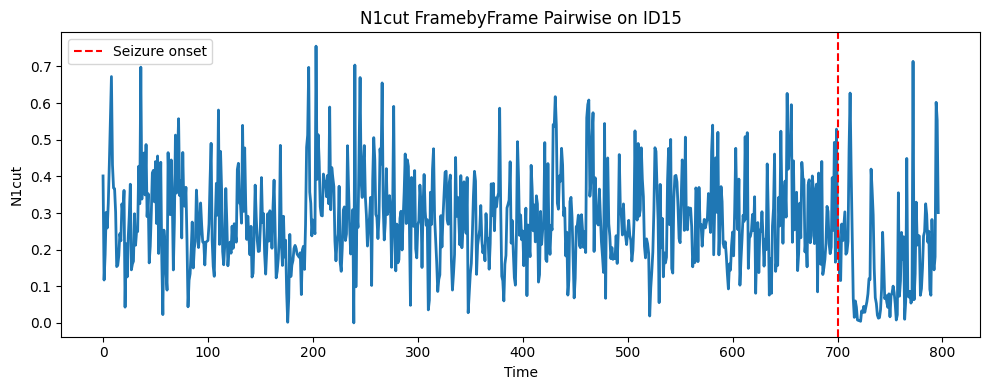

In [ ]:
plot_n1cut(n1_frame_series, ID, type_pair_frame, onset_window)

In [ ]:
times_abs_frame = []
phase_labels_frame = []
n1_values_frame = []
n1_diff_1_frame = []
edge_counts_frame = []
avg_strengths_frame = []
avg_weights_frame = []


In [ ]:
for t in range(W):

    t_abs = t * dt
    phase = "pre_ictal" if t < onset_window else "ictal"

    # build graph
    w_t = mi_full[:, t]
    mask = select_edges_topM_topK(links_ids, w_t, N, M)
    G = build_weighted_graph(node_ids, links_ids, w_t, mask)

    _, n1, _ = ncut_n1cut_from_igraph(G)
    n1_values_frame.append(n1)

    # pairwise difference
    if len(n1_values_frame) > 1:
        n1_diff_1_frame.append(abs(n1_values_frame[-1] - n1_values_frame[-2]))
    else:
        n1_diff_1_frame.append(np.nan)

    edge_counts_frame.append(G.ecount())
    avg_strengths_frame.append(
        np.mean(G.strength(weights="weight")) if G.ecount() > 0 else np.nan
    )
    avg_weights_frame.append(
        np.mean(G.es["weight"]) if G.ecount() > 0 else np.nan
    )

    times_abs_frame.append(t_abs)
    phase_labels_frame.append(phase)

# convert to arrays
times_abs_frame = np.array(times_abs_frame)
phase_labels_frame = np.array(phase_labels_frame)

n1_values_frame = np.array(n1_values_frame)
n1_diff_1_frame = np.array(n1_diff_1_frame)

edge_counts_frame = np.array(edge_counts_frame)
avg_strengths_frame = np.array(avg_strengths_frame)
avg_weights_frame = np.array(avg_weights_frame)

pre_mask_frame = (phase_labels_frame == "pre_ictal")
ict_mask_frame = (phase_labels_frame == "ictal")


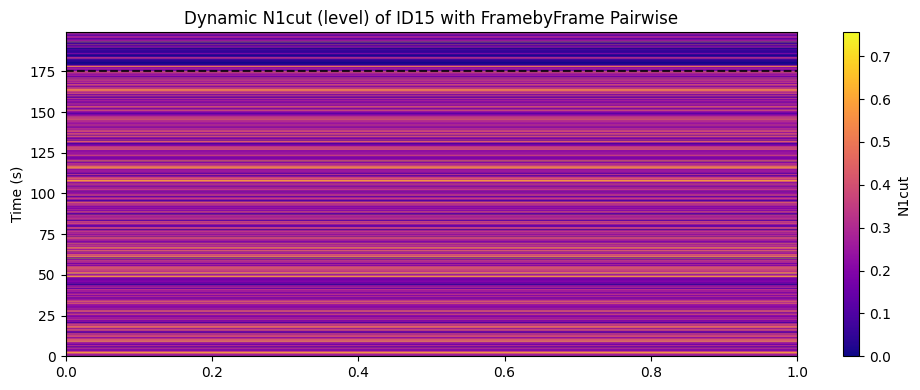

In [ ]:
onset_s = onset_window * dt 

plot_n1cut_level_heatmap(
    n1_values_frame,
    times_abs_frame,
    onset_s,
    ID,
    type_pair_frame
)


In [ ]:
n1_delta_frame = np.abs(np.diff(n1_frame_series)) # absolut variation between consecutive windows 
times_abs_delta_frame = times_abs_frame[1:] #to allinate labes 
phase_labels_delta_frame = phase_labels_frame[1:] 
pre_mask_d_frame = phase_labels_delta_frame == "pre_ictal" 
ict_mask_d_frame = phase_labels_delta_frame == "ictal" 

print("N1cut temporal instability") 
print(f"Mean |delta N1cut| pre-ictal : {np.nanmean(n1_delta_frame[pre_mask_d_frame]):.4f}") 
print(f"Mean |delta N1cut| ictal : {np.nanmean(n1_delta_frame[ict_mask_d_frame]):.4f}") 
print(f"Median |delta N1cut| pre-ictal : {np.nanmedian(n1_delta_frame[pre_mask_d_frame]):.4f}") 
print(f"Median |delta N1cut| ictal : {np.nanmedian(n1_delta_frame[ict_mask_d_frame]):.4f}")

N1cut temporal instability
Mean |delta N1cut| pre-ictal : 0.1083
Mean |delta N1cut| ictal : 0.0942
Median |delta N1cut| pre-ictal : 0.0828
Median |delta N1cut| ictal : 0.0448


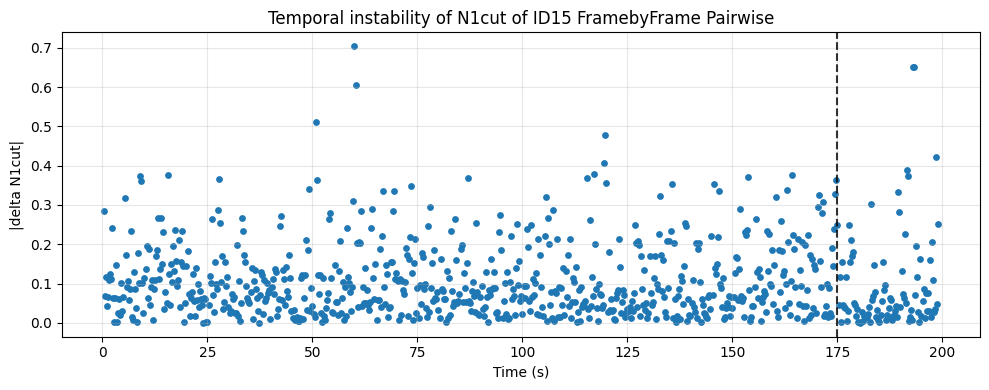

In [ ]:
plot_temporal_instability(times_abs_delta_frame, n1_delta_frame, ID, type_pair_frame)

# Anticipation analysis

In [ ]:
pre_mask_frame = times_abs_frame < onset_s

t_pre_frame = times_abs_frame[pre_mask_frame]
n1_pre_frame = n1_frame_series[pre_mask_frame]
# work with negative temporal for comoditiy
t_rel_pre_frame = t_pre_frame - onset_s   # negativ time (before of onset)

In [ ]:
#smoothing 
n1_pre_smooth_frame = moving_average(n1_pre_frame, w)
t_rel_pre_smooth_frame = t_rel_pre_frame[w-1:]


In [ ]:
rho_frame, pval_frame = spearmanr(t_rel_pre_smooth_frame, n1_pre_smooth_frame)
print(f"Spearman rho = {rho_frame:.3f}, p = {pval_frame:.4f}")
# i need to use Spearman beacuse dosent' assume linearity

Spearman rho = -0.008, p = 0.8407


In [ ]:
if pval_frame > 0.05:
    print(f'for patient {ID} the anticipation analysis performed on pre-ictal N1cut values did not reveal a significant monotonic trend toward seizure onset')
else: print(f'for patient {ID} the anticipation analysis performed on pre-ictal N1cut values REVEAL a significant monotonic trend toward seizure onset')


for patient ID15 the anticipation analysis performed on pre-ictal N1cut values did not reveal a significant monotonic trend toward seizure onset


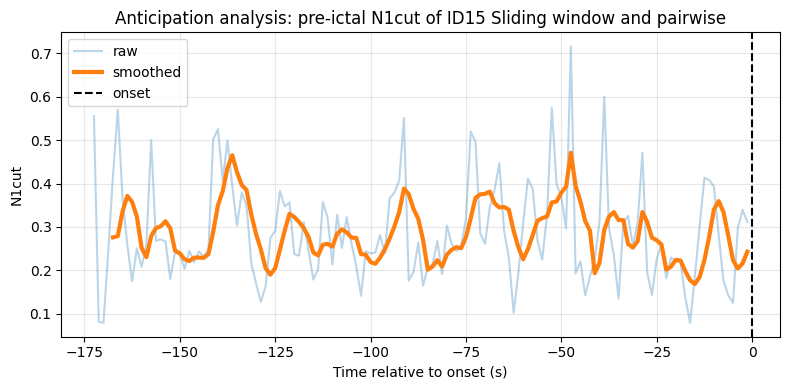

In [ ]:
plt.figure(figsize=(8,4))   

plt.plot(t_rel_pre, n1_pre, alpha=0.3, label="raw")
plt.plot(t_rel_pre_smooth, n1_pre_smooth, lw=3, label="smoothed")

plt.axvline(0, ls="--", c="k", label="onset")

plt.xlabel("Time relative to onset (s)")
plt.ylabel("N1cut")
plt.title(f"Anticipation analysis: pre-ictal N1cut of {ID} {type_my}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Chancing point verification

In [ ]:
signal_frame = n1_pre_smooth_frame
algo_frame = rpt.Pelt(model="rbf").fit(signal_frame)
bkpts_frame = algo_frame.predict(pen=5)

print("Change points (indices):", bkpts_frame)
print("Change points (seconds):", t_rel_pre_smooth_frame[bkpts_frame[:-1]])


Change points (indices): [30, 75, 170, 190, 220, 696]
Change points (seconds): [-166.5  -155.25 -131.5  -126.5  -119.  ]


# Directional anticipation

In [ ]:
times_abs_delta_frame = times_abs_frame[1:]

pre_mask_d_frame  = times_abs_delta_frame < onset_s
post_mask_d_frame = (times_abs_delta_frame >= onset_s) & (times_abs_delta_frame < onset_s + 30)

print("Mean |ΔN1cut| pre :", np.nanmean(n1_delta_frame[pre_mask_d_frame]))
print("Mean |ΔN1cut| early ictal :", np.nanmean(n1_delta_frame[post_mask_d_frame]))


Mean |ΔN1cut| pre : 0.10830641925834103
Mean |ΔN1cut| early ictal : 0.09419779760660503


# Phase-specific distribution analysis


In [ ]:
n1_pre_frame = n1_values_frame[pre_mask_frame]
n1_ict_frame = n1_values_frame[ict_mask_frame]
print(len(n1_pre), len(n1_ict))

138 18


/tmp/ipykernel_120294/242127285.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([n1_pre_frame, n1_ict_frame], labels=["Pre-ictal", "Ictal"], showfliers=True)


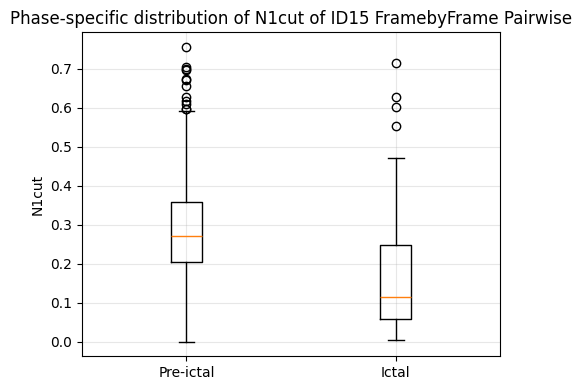

In [ ]:

plt.figure(figsize=(5,4))
plt.boxplot([n1_pre_frame, n1_ict_frame], labels=["Pre-ictal", "Ictal"], showfliers=True)
plt.ylabel("N1cut")
plt.title(f"Phase-specific distribution of N1cut of {ID} {type_pair_frame}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print("Pre-ictal:", summarize_dist(n1_pre_frame))
print("Ictal   :", summarize_dist(n1_ict_frame))

Pre-ictal: {'mean': np.float64(0.2865173087388625), 'median': np.float64(0.2709532000998209), 'std': np.float64(0.12290780183433525), 'iqr': np.float64(0.1552216553307445)}
Ictal   : {'mean': np.float64(0.1641361768169572), 'median': np.float64(0.1146052368555897), 'std': np.float64(0.14893355824247292), 'iqr': np.float64(0.18934045145567532)}


In [ ]:
U, p = mannwhitneyu(n1_pre_frame, n1_ict_frame, alternative="two-sided")#Recurrence quantification analysis of dynamic brain networks
 #the distribution are different?
print(f"Mann–Whitney U test: p = {p:.4e}")

Mann–Whitney U test: p = 1.0442e-17


# Entropy

In [ ]:
#mask for entroby, otw give me errors for different size
window=10
pre_mask_ent_frame = pre_mask_frame[window-1:]
ict_mask_ent_frame = ict_mask_frame[window-1:]

ent_n1_frame = dynamic_entropy(n1_frame_series, window=10)

print(f"mean pre_mask_ent: {np.nanmean(ent_n1_frame[pre_mask_ent_frame])}")
print(f"mean post_mask_ent: {np.nanmean(ent_n1_frame[ict_mask_ent_frame])}")


mean pre_mask_ent: 1.7855701382911167
mean post_mask_ent: 1.6026385053076284


# Memory analysis

In [ ]:
r2_lag1_frame = lagged_predictability(n1_frame_series, lag=1)
r2_lag5_frame = lagged_predictability(n1_frame_series, lag=5)

print("Lag-1 predictability (R^2):", r2_lag1_frame)
print("Lag-5 predictability (R^2):", r2_lag5_frame)


Lag-1 predictability (R^2): 0.1599571138264108
Lag-5 predictability (R^2): 0.013973746809830788


In [ ]:
r2_pre_frame  = lagged_predictability(n1_frame_series[pre_mask_frame], lag=1)
r2_ict_frame  = lagged_predictability(n1_frame_series[ict_mask_frame], lag=1)

print("Lag-1 R^2 pre-ictal :", r2_pre_frame)
print("Lag-1 R^2 ictal     :", r2_ict_frame)

Lag-1 R^2 pre-ictal : 0.09924163904551146
Lag-1 R^2 ictal     : 0.21423904575746502



# HDB Scan

by strength

In [ ]:
#sepration of windows 
pre_graphs  = dynamic_igraphs_full[:onset_dyn]
ict_graphs  = dynamic_igraphs_full[onset_dyn:]


In [ ]:
#compute the strength, the node is described like [strength_pre(i), strength_ict(i)]
N = dynamic_igraphs_full[0].vcount()

strength_pre  = np.zeros(N)
strength_ict  = np.zeros(N)

# PRE
for G in pre_graphs:
    if G.ecount() > 0:
        strength_pre += np.array(G.strength(weights="weight"))
strength_pre /= len(pre_graphs)

# ICTAL
for G in ict_graphs:
    if G.ecount() > 0:
        strength_ict += np.array(G.strength(weights="weight"))
strength_ict /= len(ict_graphs)


In [ ]:
X_nodes = np.column_stack([strength_pre, strength_ict])
#normalization

X_nodes = StandardScaler().fit_transform(X_nodes)


In [ ]:

#applaied hdbscan
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=2
)

labels_nodes = clusterer.fit_predict(X_nodes)


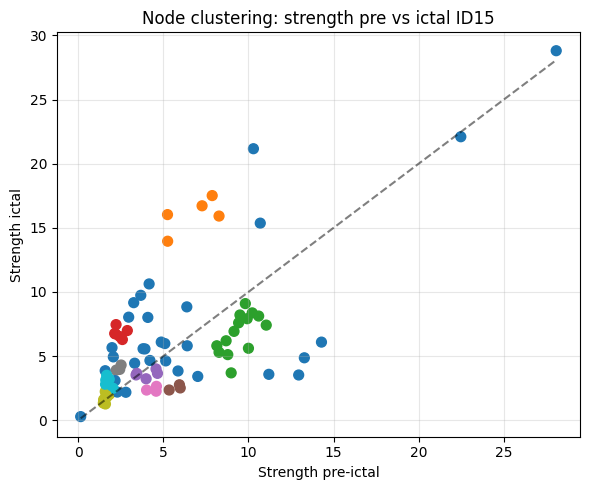

In [ ]:
#visualization
plt.figure(figsize=(6,5))
plt.scatter(
    strength_pre,
    strength_ict,
    c=labels_nodes,
    cmap="tab10",
    s=50
)
plt.plot(
    [strength_pre.min(), strength_pre.max()],
    [strength_pre.min(), strength_pre.max()],
    "--k", alpha=0.5
)
plt.xlabel("Strength pre-ictal")
plt.ylabel("Strength ictal")
plt.title(f"Node clustering: strength pre vs ictal {ID}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:


df = pd.DataFrame({
    "node": node_ids,
    "cluster": labels_nodes,
    "strength_pre": strength_pre,
    "strength_ict": strength_ict
})

df_sorted = df.sort_values(["cluster", "strength_pre"])

print(df_sorted)


    node  cluster  strength_pre  strength_ict
4    4.0       -1      0.150230      0.284913
43  43.0       -1      1.590284      3.861933
48  48.0       -1      1.989641      5.659390
55  55.0       -1      2.067245      4.939929
62  62.0       -1      2.167956      3.090653
..   ...      ...           ...           ...
63  63.0        8      1.676050      3.506822
47  47.0        8      1.729087      3.399934
69  69.0        8      1.826703      3.194678
21  21.0        8      1.931451      2.545243
72  72.0        8      2.047888      2.492991

[86 rows x 4 columns]


In [ ]:
summary = (
    df
    .groupby("cluster")
    .agg(
        n_nodes=("node", "count"),
        mean_pre=("strength_pre", "mean"),
        mean_ict=("strength_ict", "mean"),
        std_pre=("strength_pre", "std"),
        std_ict=("strength_ict", "std")
    )
    .sort_index()
)

print(summary)


         n_nodes  mean_pre   mean_ict   std_pre   std_ict
cluster                                                  
-1            31  6.792473   7.488533  6.199683  6.316141
 0             5  6.786022  16.025745  1.443844  1.321890
 1            14  9.469704   6.811841  0.856516  1.550134
 2             6  2.417994   6.792241  0.287403  0.401811
 3             5  4.014941   3.615443  0.597308  0.275389
 4             3  5.763205   2.548451  0.362236  0.205807
 5             3  4.399256   2.421628  0.329337  0.197977
 6             3  2.401347   4.059928  0.147747  0.214618
 7             9  1.658637   1.806922  0.133632  0.335569
 8             7  1.778073   3.010586  0.164838  0.403821


In [ ]:
df["delta_strength"] = df["strength_ict"] - df["strength_pre"]
df_outliers = df[df["cluster"] == -1].copy()
df_outliers = df_outliers.sort_values("delta_strength", ascending=False)

print(df_outliers)


    node  cluster  strength_pre  strength_ict  delta_strength
38  38.0       -1     10.293096     21.165173       10.872076
37  37.0       -1      4.168809     10.626187        6.457377
10  10.0       -1      3.678921      9.738492        6.059571
9    9.0       -1      3.264044      9.165311        5.901267
54  54.0       -1      2.969488      8.035498        5.066011
30  30.0       -1     10.694804     15.363942        4.669138
8    8.0       -1      4.093457      8.017368        3.923911
48  48.0       -1      1.989641      5.659390        3.669748
55  55.0       -1      2.067245      4.939929        2.872684
52  52.0       -1      6.382419      8.838368        2.455949
43  43.0       -1      1.590284      3.861933        2.271649
78  78.0       -1      3.813110      5.574868        1.761758
50  50.0       -1      3.925806      5.560990        1.635184
7    7.0       -1      4.881260      6.094235        1.212975
35  35.0       -1      3.319198      4.447532        1.128335
62  62.0

Node stability vs variability

In [ ]:
# Built the seires of strength for node

N = dynamic_igraphs_full[0].vcount()
T = len(dynamic_igraphs_full)

strength_dyn = np.zeros((N, T))

for t, G in enumerate(dynamic_igraphs_full):
    if G.ecount() > 0:
        strength_dyn[:, t] = np.array(G.strength(weights="weight"))
    else:
        strength_dyn[:, t] = 0.0


In [ ]:
# feature for node
mean_strength = strength_dyn.mean(axis=1)
std_strength  = strength_dyn.std(axis=1)

X_nodes2 = np.column_stack([mean_strength, std_strength])
# normalization 
X_nodes2 = StandardScaler().fit_transform(X_nodes2)

In [ ]:
# applaied HDBSCAN
clusterer2 = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=2
)

labels_nodes2 = clusterer2.fit_predict(X_nodes2)


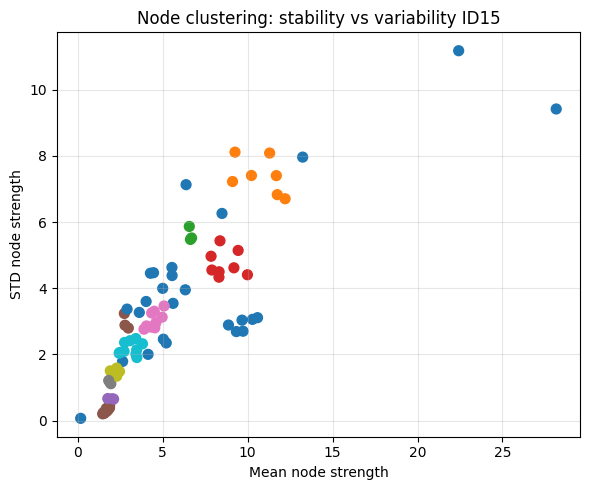

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(
    mean_strength,
    std_strength,
    c=labels_nodes2,
    cmap="tab10",
    s=50
)
plt.xlabel("Mean node strength")
plt.ylabel("STD node strength")
plt.title(f"Node clustering: stability vs variability {ID}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
df2 = pd.DataFrame({
    "node": node_ids,
    "cluster": labels_nodes2,
    "mean_strength": mean_strength,
    "std_strength": std_strength
})

summary2 = (
    df2
    .groupby("cluster")
    .agg(
        n_nodes=("node", "count"),
        mean_mean=("mean_strength", "mean"),
        mean_std=("std_strength", "mean")
    )
    .sort_index()
)

print(summary2)

# to remember
# mean_strength H std_strength L, stable hub
# mean_strength H std_strength H, dyanmic hub
# mean_strength L std_strength L, stable periferic 
# mean_strength L std_strength H, errors nodes (not stable in the time)
# mean_strength extrene, std_strength extreme = outlier


         n_nodes  mean_mean  mean_std
cluster                              
-1            20   7.157861  4.512881
 0             6   9.743460  2.913016
 1             7  10.787399  7.394498
 2             3   6.630121  5.619875
 3             8   8.668071  4.742588
 4             3   1.959567  0.657123
 5             9   1.677648  0.307082
 6             3   2.829713  2.971589
 7             9   4.470482  3.038680
 8             3   1.880861  1.163141
 9             5   2.187567  1.467701
 10            4   2.593231  2.136469
 11            6   3.441240  2.210159


In [ ]:

df2["cv_strength"] = df2["std_strength"] / df2["mean_strength"]
df2_outliers = df2[df2["cluster"] == -1].copy()

# reorder for variability
df2_outliers = df2_outliers.sort_values("std_strength", ascending=False)




In [ ]:
print(
    df2_outliers[
        ["node", "mean_strength", "std_strength", "cv_strength"]
    ]
)


    node  mean_strength  std_strength  cv_strength
56  56.0      22.422647     11.178043     0.498516
39  39.0      28.166716      9.416826     0.334325
15  15.0      13.237954      7.962647     0.601501
11  11.0       6.372200      7.129553     1.118853
64  64.0       8.488062      6.259432     0.737440
58  58.0       5.540079      4.626824     0.835155
10  10.0       4.455789      4.468044     1.002750
75  75.0       4.273425      4.452402     1.041881
84  84.0       5.550238      4.382209     0.789553
37  37.0       4.996678      3.995319     0.799595
18  18.0       6.328125      3.951235     0.624393
9    9.0       4.020616      3.598361     0.894978
0    0.0       5.606128      3.541830     0.631778
66  66.0       2.897798      3.368108     1.162299
54  54.0       3.618976      3.267701     0.902935
7    7.0       5.036770      2.458620     0.488134
23  23.0       5.204538      2.345650     0.450693
50  50.0       4.135445      2.000741     0.483803
46  46.0       2.637540      1.

Fiedler-based node analysis

In [ ]:
# filder fun
def fiedler_from_igraph(G):
    n = G.vcount()
    if G.ecount() == 0:
        return np.full(n, np.nan)

    W = np.zeros((n, n))
    edges = G.get_edgelist()
    weights = np.array(G.es["weight"], dtype=float)

    for (u, v), w in zip(edges, weights):
        W[u, v] += w
        W[v, u] += w

    d = W.sum(axis=1)
    D = np.diag(d)
    L = D - W

    evals, evecs = np.linalg.eigh(L)
    if len(evals) < 2:
        return np.full(n, np.nan)

    return evecs[:, 1]   


In [ ]:
# each node is desbribed from [Fiedler_pre(i), Fiedler_ict(i)]
pre_graphs = dynamic_igraphs_full[:onset_dyn]
ict_graphs = dynamic_igraphs_full[onset_dyn:]

N = dynamic_igraphs_full[0].vcount()

fiedler_pre = np.zeros(N)
fiedler_ict = np.zeros(N)

# PRE
cnt = 0
for G in pre_graphs:
    f = fiedler_from_igraph(G)
    if not np.all(np.isnan(f)):
        fiedler_pre += f
        cnt += 1
fiedler_pre /= cnt

# ICTAL
cnt = 0
for G in ict_graphs:
    f = fiedler_from_igraph(G)
    if not np.all(np.isnan(f)):
        fiedler_ict += f
        cnt += 1
fiedler_ict /= cnt


In [ ]:

X_nodes3 = np.column_stack([fiedler_pre, fiedler_ict])

X_nodes3 = StandardScaler().fit_transform(X_nodes3)

clusterer3 = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=2
)

labels_nodes3 = clusterer3.fit_predict(X_nodes3)


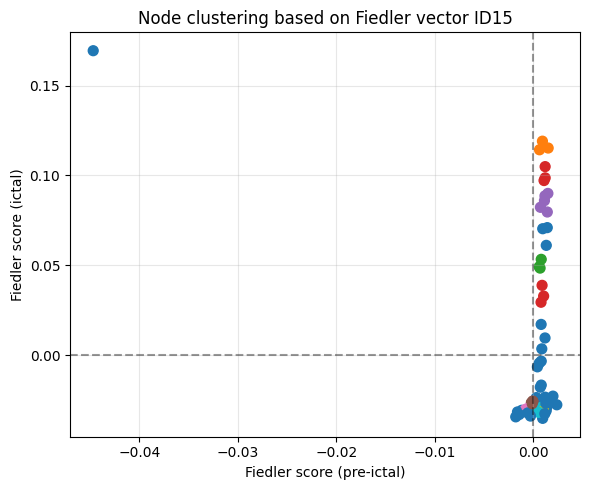

In [ ]:

plt.figure(figsize=(6,5))
plt.scatter(
    fiedler_pre,
    fiedler_ict,
    c=labels_nodes3,
    cmap="tab10",
    s=50
)

plt.axhline(0, ls="--", c="k", alpha=0.4)
plt.axvline(0, ls="--", c="k", alpha=0.4)

plt.xlabel("Fiedler score (pre-ictal)")
plt.ylabel("Fiedler score (ictal)")
plt.title(f"Node clustering based on Fiedler vector {ID}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
df3 = pd.DataFrame({
    "node": node_ids,
    "cluster": labels_nodes3,
    "fiedler_pre": fiedler_pre,
    "fiedler_ict": fiedler_ict
})

df3["delta_fiedler"] = df3["fiedler_ict"] - df3["fiedler_pre"]

summary3 = (
    df3
    .groupby("cluster")
    .agg(
        n_nodes=("node", "count"),
        mean_pre=("fiedler_pre", "mean"),
        mean_ict=("fiedler_ict", "mean"),
        mean_delta=("delta_fiedler", "mean")
    )
    .sort_index()
)

print(summary3)
# delta pos = dirver (more important)
# delta neg = other side of the cut 

         n_nodes  mean_pre  mean_ict  mean_delta
cluster                                         
-1            28 -0.001030 -0.009293   -0.008263
 0             5  0.000781 -0.000305   -0.001086
 1             3  0.001028  0.116168    0.115140
 2             3  0.000705  0.050275    0.049569
 3             3  0.000914  0.033665    0.032751
 4             3  0.001171  0.100200    0.099028
 5             5  0.001194  0.085265    0.084071
 6             7 -0.000110 -0.026523   -0.026413
 7             4 -0.000704 -0.030285   -0.029582
 8             3 -0.000387 -0.031273   -0.030886
 9             5  0.000014 -0.030338   -0.030352
 10            5  0.001001 -0.030498   -0.031499
 11            8  0.000519 -0.030459   -0.030978
 12            4  0.000759 -0.029260   -0.030019


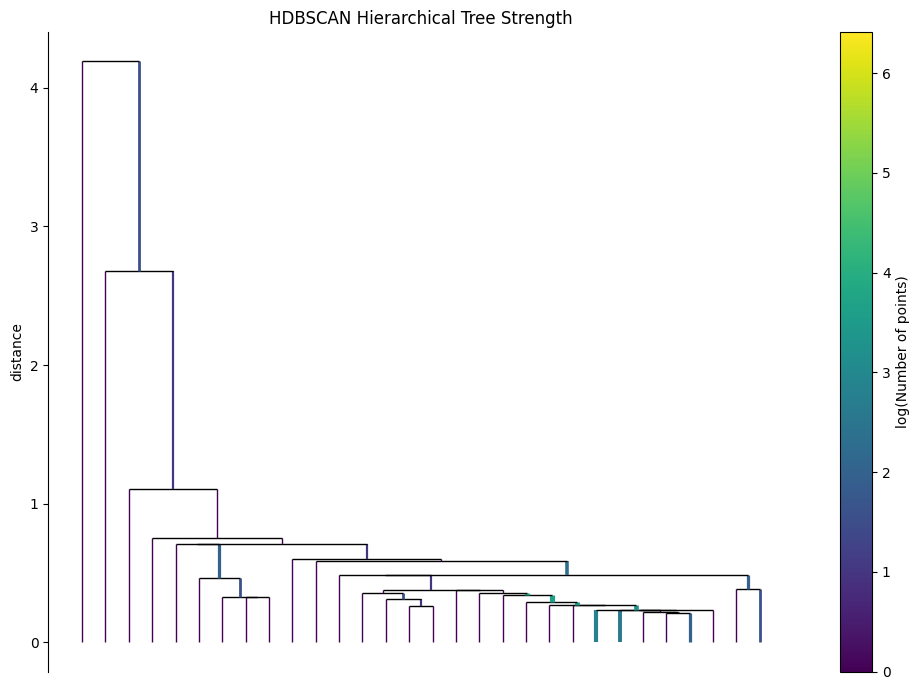

In [ ]:
plt.figure(figsize=(10,7))

clusterer.single_linkage_tree_.plot(
    truncate_mode='lastp',
    p=30   
)

plt.title("HDBSCAN Hierarchical Tree Strength")
plt.tight_layout()
plt.show()


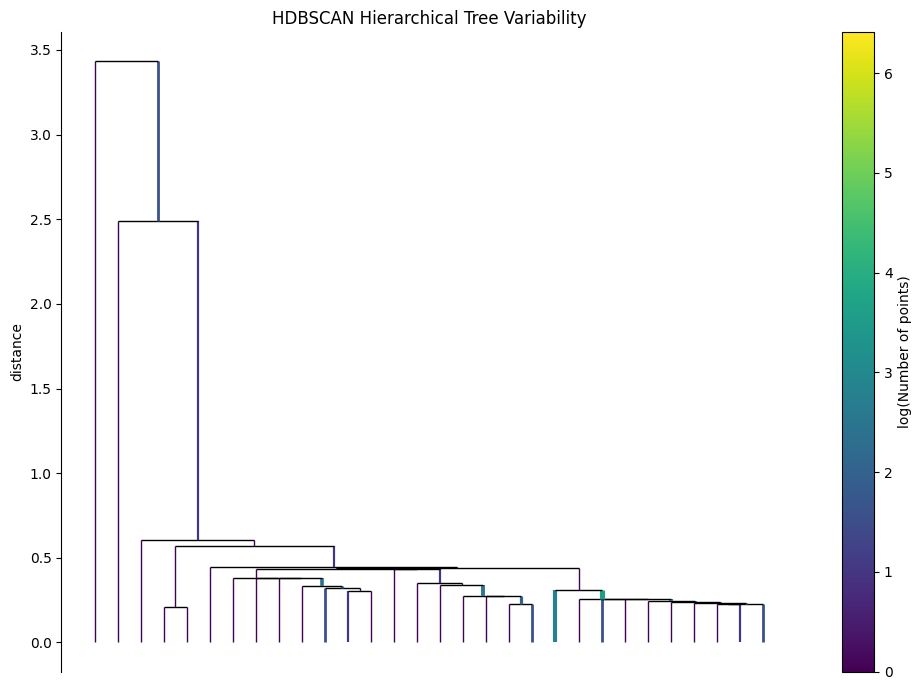

In [ ]:
plt.figure(figsize=(10,7))

clusterer2.single_linkage_tree_.plot(
    truncate_mode='lastp',
    p=30   
)

plt.title("HDBSCAN Hierarchical Tree Variability")
plt.tight_layout()
plt.show()


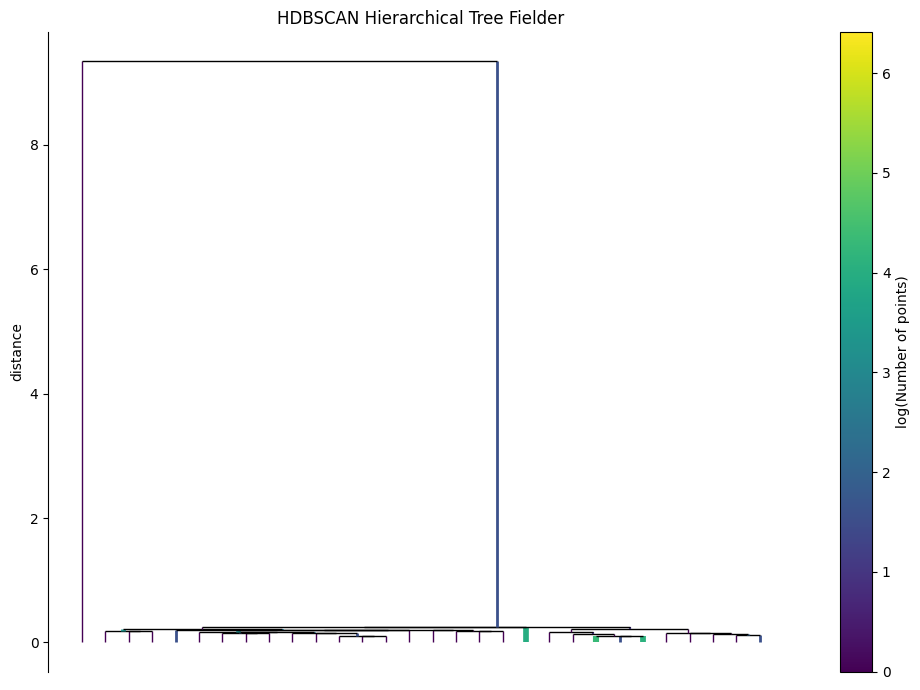

In [ ]:
plt.figure(figsize=(10,7))

clusterer3.single_linkage_tree_.plot(
    truncate_mode='lastp',
    p=30   
)

plt.title("HDBSCAN Hierarchical Tree Fielder")
plt.tight_layout()
plt.show()


# Overlapping of the 3 results

In [ ]:
#chaningn of the strength only the top
thr1 = np.percentile(np.abs(df["delta_strength"]), 80)
nodes_A1 = set(df.loc[np.abs(df["delta_strength"]) > thr1, "node"])


In [ ]:
#instable nodes only th top
thr2 = np.percentile(df2["std_strength"], 80)
nodes_A2 = set(df2.loc[df2["std_strength"] > thr2, "node"])


In [ ]:
#relevant spectral nodes, only the top
thr3 = np.percentile(np.abs(df3["delta_fiedler"]), 80)
nodes_A3 = set(df3.loc[np.abs(df3["delta_fiedler"]) > thr3, "node"])


In [ ]:
#overlapping
A12 = nodes_A1 & nodes_A2
A13 = nodes_A1 & nodes_A3
A23 = nodes_A2 & nodes_A3
A123 = nodes_A1 & nodes_A2 & nodes_A3
print("A1 (strength change):", len(nodes_A1))
print("A2 (instability):", len(nodes_A2))
print("A3 (spectral role):", len(nodes_A3))

print("A1 ∩ A2:", len(A12))
print("A1 ∩ A3:", len(A13))
print("A2 ∩ A3:", len(A23))
print("A1 ∩ A2 ∩ A3:", len(A123))



A1 (strength change): 17
A2 (instability): 17
A3 (spectral role): 17
A1 ∩ A2: 11
A1 ∩ A3: 4
A2 ∩ A3: 6
A1 ∩ A2 ∩ A3: 4


In [ ]:
core_nodes = sorted(A123)
print("CORE NODES: The only nodes that change strength (A1), instable during the time (A2) and drive the spectral bipartition (A3)")
print(core_nodes)


CORE NODES: The only nodes that change strength (A1), instable during the time (A2) and drive the spectral bipartition (A3)
[3.0, 14.0, 15.0, 17.0]


# Triangles

In [ ]:

# Triadic higher-order measures
dtct      = load_data(WD, ID, "dual_total_correlations_per_triangle.npz")  # (T_tri, W)
tr_ids    = load_data(WD, ID, "triangle_ids.npz")                          # (T_tri, 3)

# Pairwise structure (needed for projection)
links_ids = load_data(WD, ID, "link_ids.npz")                               # (L_links, 2)
node_ids  = load_data(WD, ID, "node_ids.npz")                               # (N_nodes,)

tr_ids    = tr_ids.astype(int)
links_ids = links_ids.astype(int)
node_ids  = node_ids.astype(int)
N = len(node_ids)
T_tri, W = dtct.shape

fractions = np.linspace(0, 1, 48)
early_cut = 0.3

M_tri = 25
PERC_LINK = 15

early_mask = fractions <= early_cut
fractions_early = fractions[early_mask]

pair_to_idx = {tuple(sorted((int(u), int(v)))): i for i, (u, v) in enumerate(links_ids)}
L = links_ids.shape[0]

def threshold_links_by_weight(w, perc=80):
    w = np.asarray(w, float)
    mask = np.zeros_like(w, dtype=bool)
    w_pos = w[w > 0]
    if w_pos.size == 0:
        return mask
    thr = np.percentile(w_pos, perc)
    mask[w >= thr] = True
    return mask


In [ ]:
def tri_auc(curve, x):
    curve = np.asarray(curve, float)
    x = np.asarray(x, float)
    return float(np.trapezoid(curve, x))

def tri_auc_up_to(curve, x, cut=0.3):
    curve = np.asarray(curve, float)
    x = np.asarray(x, float)
    mask = x < cut
    x_trunc = np.append(x[mask], cut)
    y_trunc = np.append(curve[mask], np.interp(cut, x, curve))
    return float(np.trapezoid(y_trunc, x_trunc))

In [ ]:
def build_graph(node_ids, links_ids, weights, mask):
    G = nx.Graph()
    G.add_nodes_from([int(n) for n in node_ids])
    idx_keep = np.where(mask & (weights > 0))[0]
    for idx in idx_keep:
        u, v = links_ids[idx]
        G.add_edge(int(u), int(v), weight=float(weights[idx]))
    return G

In [ ]:
def select_triangles_topM_topK(triangle_ids, weights, n_nodes, M):
    weights = np.asarray(weights, float)
    mask = np.zeros(weights.shape[0], dtype=bool)
    K = n_nodes * M

    idx_active = np.where(weights > 0)[0]
    if idx_active.size == 0:
        return mask

    w_active = weights[idx_active]
    if w_active.size > K:
        topk_idx = idx_active[np.argpartition(w_active, -K)[-K:]]
    else:
        topk_idx = idx_active
    mask[topk_idx] = True

    tri_per_node = [[] for _ in range(n_nodes)]
    for idx in idx_active:
        i, j, k = triangle_ids[idx]
        tri_per_node[int(i)].append((weights[idx], idx))
        tri_per_node[int(j)].append((weights[idx], idx))
        tri_per_node[int(k)].append((weights[idx], idx))

    for n in range(n_nodes):
        node_tris = tri_per_node[n]
        if not node_tris:
            continue
        if len(node_tris) <= M:
            for _, idx in node_tris:
                mask[idx] = True
        else:
            w_vals = np.array([x[0] for x in node_tris], dtype=float)
            t_idx = np.array([x[1] for x in node_tris], dtype=int)
            topm = np.argpartition(w_vals, -M)[-M:]
            mask[t_idx[topm]] = True

    return mask

def project_active_triangles_to_edges_mean(tri_w, tri_mask):
    edge_sum = np.zeros(L, float)
    edge_cnt = np.zeros(L, float)

    active = np.where(tri_mask)[0]
    for tri_idx in active:
        w = float(tri_w[tri_idx])
        i, j, k = map(int, tr_ids[tri_idx])
        for u, v in ((i, j), (i, k), (j, k)):
            idx = pair_to_idx.get(tuple(sorted((u, v))), None)
            if idx is None:
                continue
            edge_sum[idx] += w
            edge_cnt[idx] += 1.0

    w_edges = np.divide(edge_sum, edge_cnt, out=np.zeros_like(edge_sum), where=edge_cnt > 0)
    return w_edges

def build_triadic_graph_from_dtct_window(dtct_mat, t0, t1):
    tri_w = dtct_mat[:, t0:t1].mean(axis=1)
    tri_mask = select_triangles_topM_topK(tr_ids, tri_w, N, M_tri)
    w_edges = project_active_triangles_to_edges_mean(tri_w, tri_mask)
    mask_links = threshold_links_by_weight(w_edges, perc=PERC_LINK)
    G = build_graph(node_ids, links_ids, w_edges, mask_links)
    return G



In [ ]:
def triadic_n1cut_from_window(dtct_mat, t0, t1):
    G_nx = build_triadic_graph_from_dtct_window(dtct_mat, t0, t1)

    if G_nx.number_of_edges() == 0:
        return np.nan

    G_ig = ig.Graph.from_networkx(G_nx)

    _, n1cut, _ = ncut_n1cut_from_igraph(G_ig)
    return n1cut


In [ ]:
n1cut_tri_series = []

for t0 in range(0, W - window_size + 1, step):
    t1 = t0 + window_size
    n1cut_tri_series.append(
        triadic_n1cut_from_window(dtct, t0, t1)
    )

n1cut_tri_series = np.array(n1cut_tri_series)


In [ ]:
onset_dyn = int(np.floor((onset_window - window_size) / step))

print(
    "mean pre:", np.nanmean(n1cut_tri_series[:onset_dyn]),
    "mean ictal:", np.nanmean(n1cut_tri_series[onset_dyn:])
)

print(
    "median pre:", np.nanmedian(n1cut_tri_series[:onset_dyn]),
    "median ictal:", np.nanmedian(n1cut_tri_series[onset_dyn:])
)


mean pre: 0.49083320794960816 mean ictal: 0.4687020213032945
median pre: 0.48212044914645746 median ictal: 0.46238414733956235


In [ ]:
print(
    "nodes:", G.vcount(),
    "edges:", G.ecount(),
    "zero-degree nodes:", np.sum(np.array(G.strength(weights="weight")) == 0),
    "components:", len(G.components())
)


nodes: 86 edges: 376 zero-degree nodes: 0 components: 1


In [ ]:
type_tri_win='Triadic with sliding windows'


In [ ]:
print(F'{type_tri_win} mean to MACHINE LEARING FOR {ID}')
print(n1cut_tri_series)
print('###########')
print(n1cut_tri_series.shape)

Triadic with sliding windows mean to MACHINE LEARING FOR ID15
[0.47594966 0.45508612 0.46061598 0.47638023 0.47939301 0.45978581
 0.45825237 0.50734683 0.50098411 0.48252223 0.46164778 0.52817277
 0.47157016 0.58376502 0.52596523 0.46050834 0.65445499 0.50436801
 0.48635339 0.48233329 0.47703313 0.49332057 0.45099431 0.45852857
 0.46913765 0.49497948 0.43821507 0.47429679 0.47603546 0.47736807
 0.49783149 0.46912502 0.46031285 0.47600479 0.53010281 0.501588
 0.49000146 0.49713834 0.46022239 0.50228143 0.51711544 0.46840777
 0.51081484 0.55853458 0.54023749 0.52345672 0.51172573 0.45228166
 0.49810954 0.49307945 0.51640621 0.46356339 0.48841599 0.48386295
 0.48344337 0.48026506 0.47314905 0.48903162 0.50612116 0.53147547
 0.47545202 0.49445471 0.46801046 0.52185229 0.5812596  0.46531068
 0.53845133 0.47836427 0.50050154 0.48262399 0.47648426 0.55640773
 0.48634711 0.46228667 0.4705185  0.47375617 0.50683372 0.50468891
 0.47579834 0.48424536 0.46875935 0.50810215 0.49973521 0.4539932
 0.

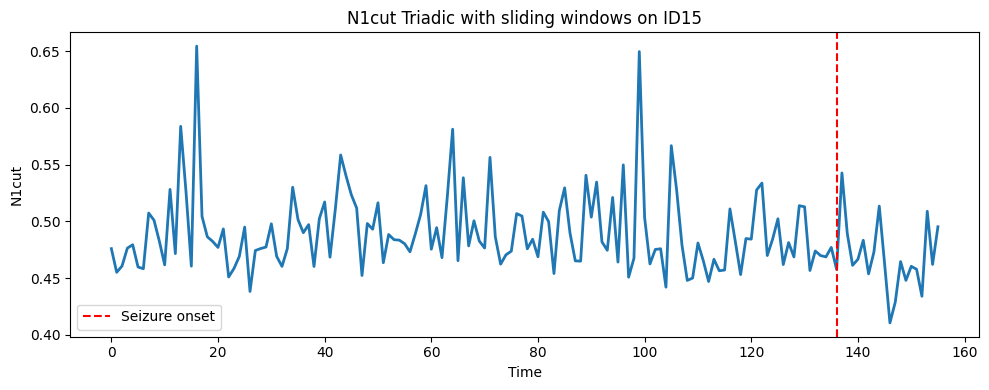

In [ ]:

plot_n1cut(n1cut_tri_series, ID, type_tri_win, onset_dyn)


In [ ]:

times_abs_tri = []        
phase_labels_tri = []    # pre / ictal
n1_values_tri = []       # N1cut(t)
n1_diff_1_tri = []       # |N1cut(t) - N1cut(t-1)|
edge_counts_tri = []
avg_strengths_tri = []
avg_weights_tri = []


In [ ]:
for t0 in range(0, W - window_size + 1, step):

    t1 = t0 + window_size
    center = 0.5 * (t0 + t1)
    t_abs = center * dt
    phase = "pre_ictal" if center < onset_window else "ictal"

    # build the triadic graph
    G_nx = build_triadic_graph_from_dtct_window(dtct, t0, t1)

    if G_nx.number_of_edges() == 0:
        n1_values_tri.append(np.nan)
        n1_diff_1_tri.append(np.nan)
        edge_counts_tri.append(0)
        avg_strengths_tri.append(np.nan)
        avg_weights_tri.append(np.nan)
    else:
        G_ig = ig.Graph.from_networkx(G_nx)

        # N1cut
        _, n1, _ = ncut_n1cut_from_igraph(G_ig)
        n1_values_tri.append(n1)

        # temporal difference
        if len(n1_values_tri) > 1 and not np.isnan(n1_values_tri[-2]):
            n1_diff_1_tri.append(abs(n1_values_tri[-1] - n1_values_tri[-2]))
        else:
            n1_diff_1_tri.append(np.nan)

        # metadata
        edge_counts_tri.append(G_ig.ecount())
        avg_strengths_tri.append(np.mean(G_ig.strength(weights="weight")))
        avg_weights_tri.append(
            np.mean(G_ig.es["weight"]) if G_ig.ecount() > 0 else np.nan
        )

    times_abs_tri.append(t_abs)
    phase_labels_tri.append(phase)

In [ ]:
times_abs_tri = np.array(times_abs_tri)
phase_labels_tri = np.array(phase_labels_tri)

n1_values_tri = np.array(n1_values_tri)
n1_diff_1_tri = np.array(n1_diff_1_tri)

edge_counts_tri = np.array(edge_counts_tri)
avg_strengths_tri = np.array(avg_strengths_tri)
avg_weights_tri = np.array(avg_weights_tri)

pre_mask_tri = (phase_labels_tri == "pre_ictal")
ict_mask_tri = (phase_labels_tri == "ictal")



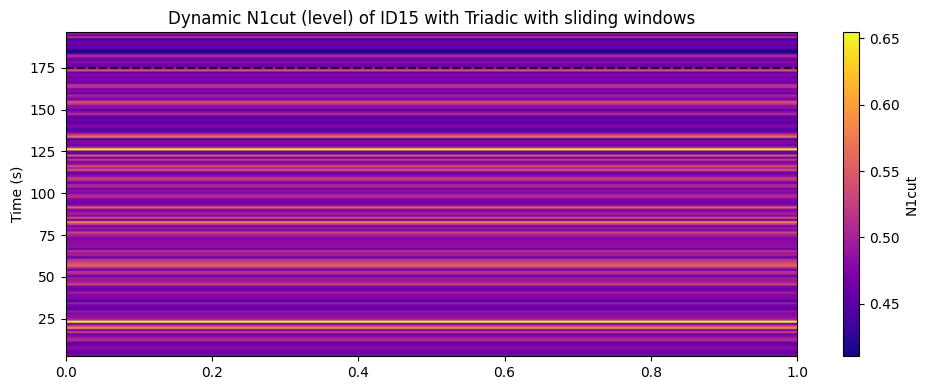

In [ ]:
onset_s = onset_window * dt

plot_n1cut_level_heatmap(
    n1_values_tri,
    times_abs_tri,
    onset_s,
    ID,
    type_tri_win
)


 temporal instability on TRIADIC N1cut

In [ ]:
n1_delta_tri = np.abs(np.diff(n1_values_tri))

times_abs_delta_tri = times_abs_tri[1:]
phase_labels_delta_tri = phase_labels_tri[1:]

pre_mask_d_tri = phase_labels_delta_tri == "pre_ictal"
ict_mask_d_tri = phase_labels_delta_tri == "ictal"

print("Triadic N1cut temporal instability")
print(f"Mean |delta N1cut| pre-ictal : {np.nanmean(n1_delta_tri[pre_mask_d_tri]):.4f}")
print(f"Mean |delta N1cut| ictal     : {np.nanmean(n1_delta_tri[ict_mask_d_tri]):.4f}")

print(f"Median |delta N1cut| pre-ictal : {np.nanmedian(n1_delta_tri[pre_mask_d_tri]):.4f}")
print(f"Median |delta N1cut| ictal     : {np.nanmedian(n1_delta_tri[ict_mask_d_tri]):.4f}")


Triadic N1cut temporal instability
Mean |delta N1cut| pre-ictal : 0.0344
Mean |delta N1cut| ictal     : 0.0311
Median |delta N1cut| pre-ictal : 0.0241
Median |delta N1cut| ictal     : 0.0289


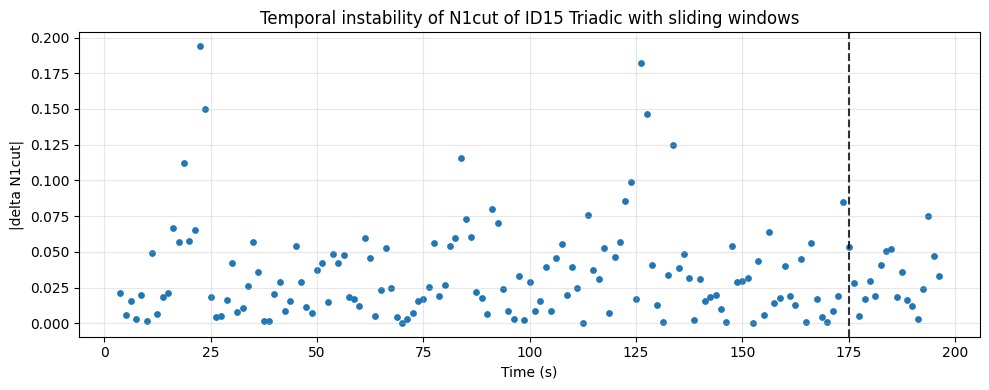

In [ ]:
plot_temporal_instability(times_abs_delta_tri, n1_delta_tri, ID, type_tri_win )


# Anticipation analysis

In [ ]:
t_pre_tri = times_abs_tri[phase_labels_tri == "pre_ictal"]
n1_pre_tri = n1_values_tri[phase_labels_tri == "pre_ictal"]


t_rel_pre_tri = t_pre_tri - onset_s


In [ ]:
w = 5
n1_pre_tri_smooth = moving_average(n1_pre_tri, w)
t_rel_pre_tri_smooth = t_rel_pre_tri[w-1:]


In [ ]:
rho_tri, pval_tri = spearmanr(t_rel_pre_tri_smooth, n1_pre_tri_smooth)

print(f"Triadic Spearman rho = {rho_tri:.3f}, p = {pval_tri:.4f}")

if pval_tri > 0.05:
    print(f'for patient {ID} the anticipation analysis performed on pre-ictal N1cut values did not reveal a significant monotonic trend toward seizure onset')
else: print(f'for patient {ID} the anticipation analysis performed on pre-ictal N1cut values REVEAL a significant monotonic trend toward seizure onset')


Triadic Spearman rho = -0.085, p = 0.3265
for patient ID15 the anticipation analysis performed on pre-ictal N1cut values did not reveal a significant monotonic trend toward seizure onset


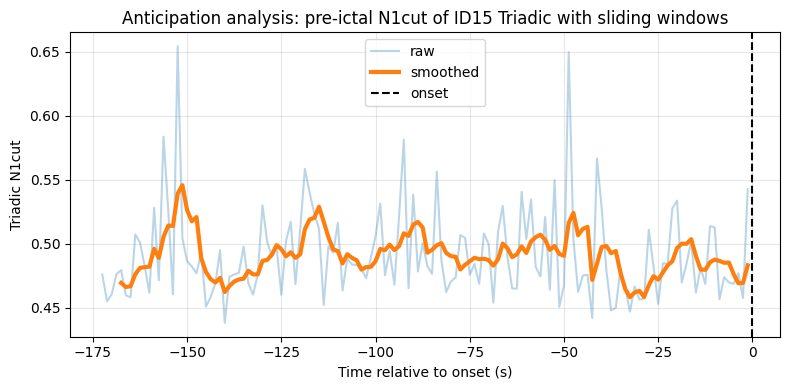

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(t_rel_pre_tri, n1_pre_tri, alpha=0.3, label="raw")
plt.plot(t_rel_pre_tri_smooth, n1_pre_tri_smooth, lw=3, label="smoothed")

plt.axvline(0, ls="--", c="k", label="onset")

plt.xlabel("Time relative to onset (s)")
plt.ylabel("Triadic N1cut")
plt.title(f"Anticipation analysis: pre-ictal N1cut of {ID} {type_tri_win}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Chancing point verification

In [ ]:
signal_tri = n1_pre_tri_smooth

algo = rpt.Pelt(model="rbf").fit(signal_tri)
bkpts_tri = algo.predict(pen=5)

print(f"Triadic change points (indices): {bkpts_tri}")
print(f"Triadic change points (seconds): {t_rel_pre_tri_smooth[bkpts_tri[:-1]]}")


Triadic change points (indices): [30, 105, 134]
Triadic change points (seconds): [-130.    -36.25]


# Directional anticipation

In [ ]:
n1_delta_tri = np.abs(np.diff(n1_values_tri))
times_abs_tri_delta = times_abs_tri[1:]
phase_labels_tri_delta = phase_labels_tri[1:]

pre_mask_tri_d = phase_labels_tri_delta == "pre_ictal"

post_mask_tri = (
    (times_abs_tri_delta > onset_s) &
    (times_abs_tri_delta < onset_s + 30)
)
print("Triadic N1cut directional asymmetry")
print(f"Mean |delta N1cut| pre :{ np.nanmean(n1_delta_tri[pre_mask_tri_d])}")
print(f"Mean |delta N1cut| early ictal :{ np.nanmean(n1_delta_tri[post_mask_tri])}")



Triadic N1cut directional asymmetry
Mean |delta N1cut| pre :0.0343945922138125
Mean |delta N1cut| early ictal :0.02982438852173218


# Phase-specific distribution analysis

/tmp/ipykernel_120294/3339857281.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


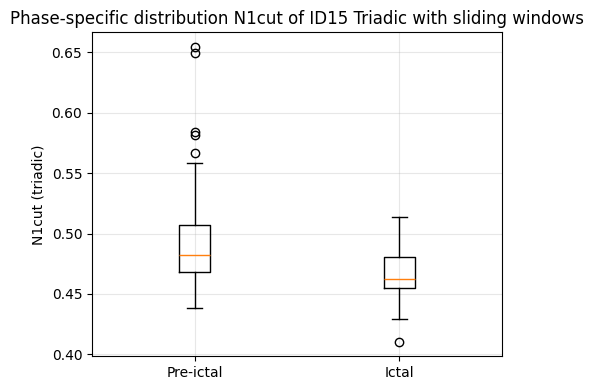

In [ ]:
n1_pre_tri = n1_values_tri[phase_labels_tri == "pre_ictal"]
n1_ict_tri = n1_values_tri[phase_labels_tri == "ictal"]

plt.figure(figsize=(5,4))
plt.boxplot(
    [n1_pre_tri, n1_ict_tri],
    labels=["Pre-ictal", "Ictal"],
    showfliers=True
)
plt.ylabel("N1cut (triadic)")
plt.title(f"Phase-specific distribution N1cut of {ID} {type_tri_win}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print("Pre-ictal:", summarize_dist(n1_pre_tri))
print("Ictal   :", summarize_dist(n1_ict_tri))


Pre-ictal: {'mean': np.float64(0.4909688964803), 'median': np.float64(0.48212044914645746), 'std': np.float64(0.035078638441006435), 'iqr': np.float64(0.03854579071488312)}
Ictal   : {'mean': np.float64(0.4652027218295113), 'median': np.float64(0.46238414733956235), 'std': np.float64(0.025771899994245045), 'iqr': np.float64(0.026039283085966147)}


In [ ]:
U, p = mannwhitneyu(n1_pre_tri, n1_ict_tri, alternative="two-sided")#Recurrence quantification analysis of dynamic brain networks
 #the distribution are different?
print(f"Mann–Whitney U test: p = {p:.4e}")


Mann–Whitney U test: p = 2.1383e-03


# Entropy

In [ ]:
# mask for entropy (triadic)
window = 10
pre_mask_ent_tri = pre_mask_tri[window-1:]
ict_mask_ent_tri = ict_mask_tri[window-1:]


In [ ]:
ent_n1_tri = dynamic_entropy(n1_values_tri, window=window)

In [ ]:
print(f"mean pre_mask_ent: {np.nanmean(ent_n1_tri[pre_mask_ent_tri])}")
print(f"mean post_mask_ent: {np.nanmean(ent_n1_tri[ict_mask_ent_tri])}")


mean pre_mask_ent: 1.7411039461884221
mean post_mask_ent: 1.7843866240932849


# Memory Analysis

In [ ]:
r2_lag1_tri = lagged_predictability(n1_values_tri, lag=1)
r2_lag5_tri = lagged_predictability(n1_values_tri, lag=5)

print("Triadic N1cut")
print("Lag-1 predictability (R^2):", r2_lag1_tri)
print("Lag-5 predictability (R^2):", r2_lag5_tri)


Triadic N1cut
Lag-1 predictability (R^2): 0.008326611539858404
Lag-5 predictability (R^2): 0.0435579129688148


In [ ]:
r2_pre_tri = lagged_predictability(n1_values_tri[pre_mask_tri], lag=1)
r2_ict_tri = lagged_predictability(n1_values_tri[ict_mask_tri], lag=1)

print("Lag-1 R^2 pre-ictal (triadic):", r2_pre_tri)
print("Lag-1 R^2 ictal     (triadic):", r2_ict_tri)


Lag-1 R^2 pre-ictal (triadic): 0.0010675516589479716
Lag-1 R^2 ictal     (triadic): 0.004614335810635615


# Triangoles FrameByFrame

In [ ]:
type_tri_frame= 'Triadic FrameByFrame'

In [ ]:
def triadic_n1cut_from_frame(dtct_mat, t):
    
    G_nx = build_triadic_graph_from_dtct_window(dtct_mat, t, t+1)

    if G_nx.number_of_edges() == 0:
        return np.nan

    G_ig = ig.Graph.from_networkx(G_nx)

    _, n1cut, _ = ncut_n1cut_from_igraph(G_ig)
    return n1cut
    
n1cut_tri_frame = []
times_abs_tri_frame = []
phase_labels_tri_frame = []

In [ ]:
for t in range(W):
    n1cut_tri_frame.append(
        triadic_n1cut_from_frame(dtct, t)
    )

    times_abs_tri_frame.append(t * dt)
    phase_labels_tri_frame.append(
        "pre_ictal" if t < onset_window else "ictal"
    )

In [ ]:
n1cut_tri_frame = np.array(n1cut_tri_frame, float)
times_abs_tri_frame = np.array(times_abs_tri_frame, float)
phase_labels_tri_frame = np.array(phase_labels_tri_frame)
pre_mask = phase_labels_tri_frame == "pre_ictal"
ict_mask = phase_labels_tri_frame == "ictal"

print(
    "mean pre:", np.nanmean(n1cut_tri_frame[pre_mask]),
    "mean ictal:", np.nanmean(n1cut_tri_frame[ict_mask])
)

print(
    "median pre:", np.nanmedian(n1cut_tri_frame[pre_mask]),
    "median ictal:", np.nanmedian(n1cut_tri_frame[ict_mask])
)


mean pre: 0.4932274755007554 mean ictal: 0.4862371817375568
median pre: 0.48550768046448156 median ictal: 0.4785441898596295


In [ ]:
print(F'{type_tri_frame} mean to MACHINE LEARING FOR {ID}')
print(n1cut_tri_frame)
print('###########')
print(n1cut_tri_frame.shape)

Traid FrameByFrame mean to MACHINE LEARING FOR ID15
[0.48367925 0.49082517 0.49913002 0.47783794 0.45812792 0.48790053
 0.47959118 0.45859617 0.53172811 0.4812504  0.53434593 0.46767849
 0.51737121 0.47399408 0.47959695 0.4535055  0.48430298 0.47390711
 0.60887675 0.45690673 0.52389786 0.49095099 0.47917457 0.58720575
 0.49465926 0.53300677 0.46687925 0.45896362 0.44492258 0.47916316
 0.482626   0.47400391 0.46804113 0.47192218 0.46296726 0.5080725
 0.51218624 0.46455181 0.54612106 0.60920379 0.47241114 0.48333179
 0.51657542 0.50129681 0.48366049 0.47045919 0.46637035 0.50680338
 0.45678541 0.45683383 0.5065007  0.45643863 0.51412057 0.4852252
 0.4660494  0.49438799 0.47995983 0.50206188 0.46882932 0.49166485
 0.47085502 0.47553707 0.51456687 0.48748375 0.44723043 0.46151881
 0.52291258 0.52606815 0.46074853 0.48125109 0.48486483 0.46115369
 0.45489549 0.4623954  0.51827708 0.47963165 0.4388346  0.77934893
 0.51523161 0.47012745 0.479151   0.49622024 0.44461873 0.48654895
 0.45161491 

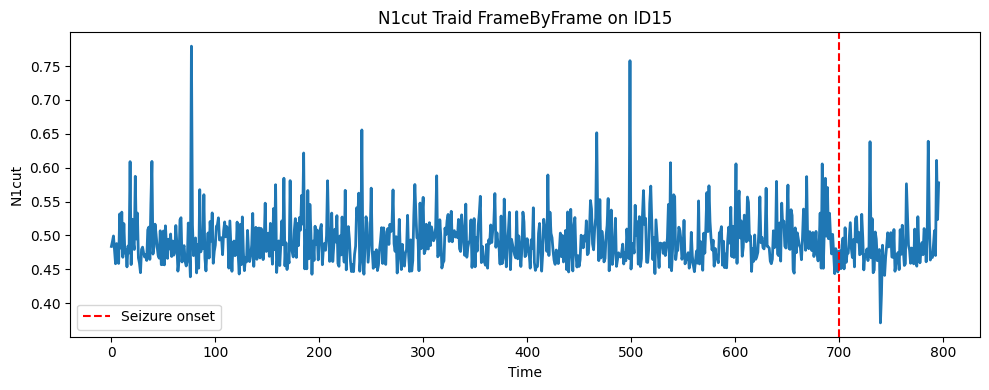

In [ ]:
plot_n1cut(n1cut_tri_frame, ID, type_tri_frame, onset_window)


In [ ]:
times_abs_tri_f = []
phase_labels_tri_f = []

n1_values_tri_f = []
n1_diff_1_tri_f = []

edge_counts_tri_f = []
avg_strengths_tri_f = []
avg_weights_tri_f = []


In [ ]:
for t in range(W):

    t_abs = t * dt
    phase = "pre_ictal" if t < onset_window else "ictal"

    
    # triadic weights at time t
    tri_w_t = dtct[:, t]

    # select active triangles
    tri_mask_t = select_triangles_topM_topK(tr_ids, tri_w_t, N, M_tri)

    # project triangles -> edges (MEAN, same as sliding)
    w_edges_t = project_active_triangles_to_edges_mean(tri_w_t, tri_mask_t)

    # threshold edges
    mask_links = threshold_links_by_weight(w_edges_t, perc=PERC_LINK)

    # build graph
    G_nx = build_graph(node_ids, links_ids, w_edges_t, mask_links)

    # compute the N1cut 
    if G_nx.number_of_edges() == 0:
        n1_values_tri_f.append(np.nan)
        n1_diff_1_tri_f.append(np.nan)
        edge_counts_tri_f.append(0)
        avg_strengths_tri_f.append(np.nan)
        avg_weights_tri_f.append(np.nan)

    else:
        G_ig = ig.Graph.from_networkx(G_nx)

        _, n1, _ = ncut_n1cut_from_igraph(G_ig)
        n1_values_tri_f.append(n1)

        # temporal difference
        if len(n1_values_tri_f) > 1 and not np.isnan(n1_values_tri_f[-2]):
            n1_diff_1_tri_f.append(abs(n1 - n1_values_tri_f[-2]))
        else:
            n1_diff_1_tri_f.append(np.nan)

    
        edge_counts_tri_f.append(G_ig.ecount())
        avg_strengths_tri_f.append(np.mean(G_ig.strength(weights="weight")))
        avg_weights_tri_f.append(
            np.mean(G_ig.es["weight"]) if G_ig.ecount() > 0 else np.nan
        )

    times_abs_tri_f.append(t_abs)
    phase_labels_tri_f.append(phase)


In [ ]:
times_abs_tri_f = np.array(times_abs_tri_f)
phase_labels_tri_f = np.array(phase_labels_tri_f)

n1_values_tri_f = np.array(n1_values_tri_f)
n1_diff_1_tri_f = np.array(n1_diff_1_tri_f)

edge_counts_tri_f = np.array(edge_counts_tri_f)
avg_strengths_tri_f = np.array(avg_strengths_tri_f)
avg_weights_tri_f = np.array(avg_weights_tri_f)

pre_mask_tri_f = phase_labels_tri_f == "pre_ictal"
ict_mask_tri_f = phase_labels_tri_f == "ictal"

print("mean pre:", np.nanmean(n1_values_tri_f[pre_mask_tri_f]),
      "mean ictal:", np.nanmean(n1_values_tri_f[ict_mask_tri_f]))

print("median pre:", np.nanmedian(n1_values_tri_f[pre_mask_tri_f]),
      "median ictal:", np.nanmedian(n1_values_tri_f[ict_mask_tri_f]))


mean pre: 0.4932274755007554 mean ictal: 0.4862371817375568
median pre: 0.48550768046448156 median ictal: 0.4785441898596295


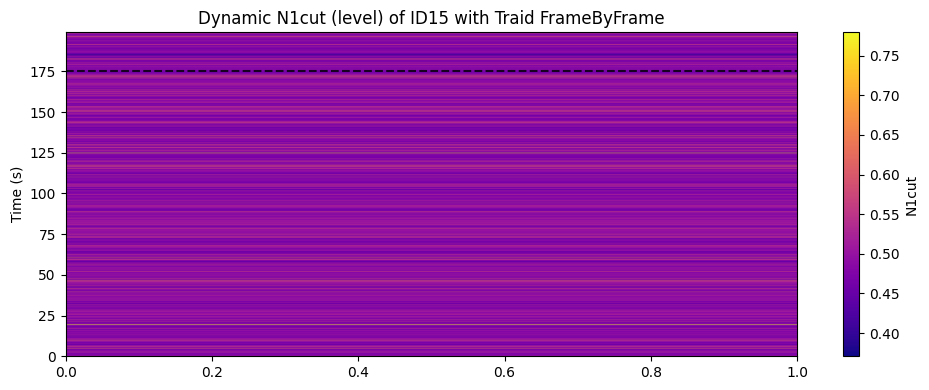

In [ ]:
onset_s = onset_window * dt

plot_n1cut_level_heatmap(
    n1_values_tri_f,
    times_abs_tri_f,
    onset_s,
    ID,
    type_tri_frame
)


In [ ]:
n1_delta_tri_f = np.abs(np.diff(n1_values_tri_f))

times_abs_delta_tri_f = times_abs_tri_f[1:]
phase_labels_delta_tri_f = phase_labels_tri_f[1:]

pre_mask_d_tri_f = phase_labels_delta_tri_f == "pre_ictal"
ict_mask_d_tri_f = phase_labels_delta_tri_f == "ictal"

print("Triadic N1cut temporal instability")
print(f"Mean |delta N1cut| pre-ictal : {np.nanmean(n1_delta_tri_f[pre_mask_d_tri_f]):.4f}")
print(f"Mean |delta N1cut| ictal     : {np.nanmean(n1_delta_tri_f[ict_mask_d_tri_f]):.4f}")

print(f"Median |delta N1cut| pre-ictal : {np.nanmedian(n1_delta_tri_f[pre_mask_d_tri_f]):.4f}")
print(f"Median |delta N1cut| ictal     : {np.nanmedian(n1_delta_tri_f[ict_mask_d_tri_f]):.4f}")


Triadic N1cut temporal instability
Mean |delta N1cut| pre-ictal : 0.0388
Mean |delta N1cut| ictal     : 0.0366
Median |delta N1cut| pre-ictal : 0.0298
Median |delta N1cut| ictal     : 0.0264


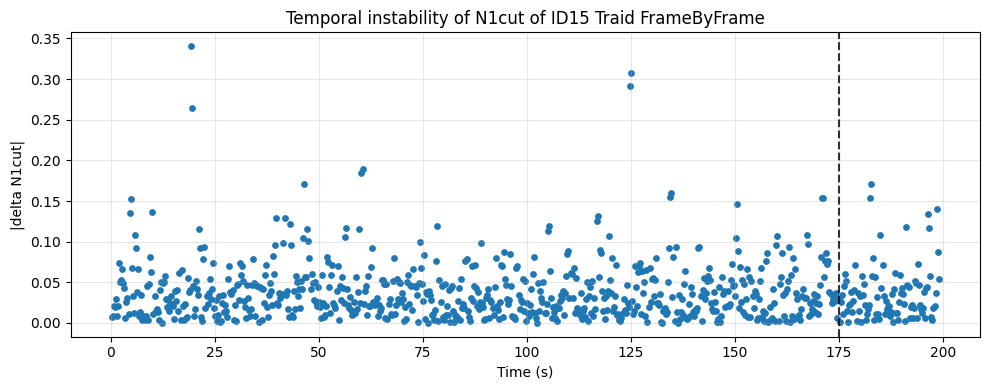

In [ ]:
plot_temporal_instability(times_abs_delta_tri_f, n1_delta_tri_f, ID, type_tri_frame)

# Anticipation analysis

In [ ]:
t_pre_tri_f = times_abs_tri_f[phase_labels_tri_f == "pre_ictal"]
n1_pre_tri_f = n1_values_tri_f[phase_labels_tri_f == "pre_ictal"]

t_rel_pre_tri_f = t_pre_tri_f - onset_s


In [ ]:
w = 5 

n1_pre_tri_f_smooth = moving_average(n1_pre_tri_f, w)
t_rel_pre_tri_f_smooth = t_rel_pre_tri_f[w-1:]


In [ ]:
rho_tri_f, pval_tri_f = spearmanr(
    t_rel_pre_tri_f_smooth,
    n1_pre_tri_f_smooth
)

print(f"Triadic (frame) Spearman rho = {rho_tri_f:.3f}, p = {pval_tri_f:.4f}")

if pval_tri_f > 0.05:
    print(f'for patient {ID} the anticipation analysis performed on pre-ictal N1cut values did not reveal a significant monotonic trend toward seizure onset')
else:
    print(f'for patient {ID} the anticipation analysis performed on pre-ictal N1cut values REVEAL a significant monotonic trend toward seizure onset')


Triadic (frame) Spearman rho = 0.082, p = 0.0313
for patient ID15 the anticipation analysis performed on pre-ictal N1cut values REVEAL a significant monotonic trend toward seizure onset


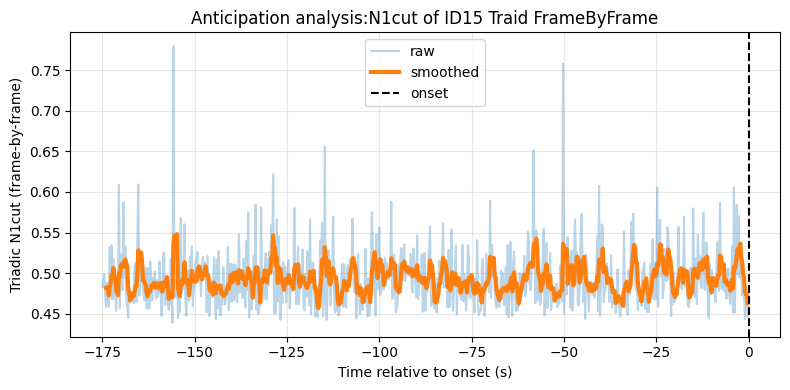

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(t_rel_pre_tri_f, n1_pre_tri_f, alpha=0.3, label="raw")
plt.plot(t_rel_pre_tri_f_smooth, n1_pre_tri_f_smooth, lw=3, label="smoothed")

plt.axvline(0, ls="--", c="k", label="onset")

plt.xlabel("Time relative to onset (s)")
plt.ylabel("Triadic N1cut (frame-by-frame)")
plt.title(f"Anticipation analysis:N1cut of {ID} {type_tri_frame}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Chancing point verification

In [ ]:
signal_tri_f = n1_pre_tri_f_smooth

algo = rpt.Pelt(model="rbf").fit(signal_tri_f)
bkpts_tri_f = algo.predict(pen=5)
print(f"Triadic change points (indices): {bkpts_tri_f}")
print(f"Triadic change points (seconds): {t_rel_pre_tri_f_smooth[bkpts_tri_f[:-1]]}")


Triadic change points (indices): [135, 250, 290, 340, 590, 696]
Triadic change points (seconds): [-140.25 -111.5  -101.5   -89.    -26.5 ]


# Phase-specific distribution analysis

/tmp/ipykernel_120294/3526586085.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


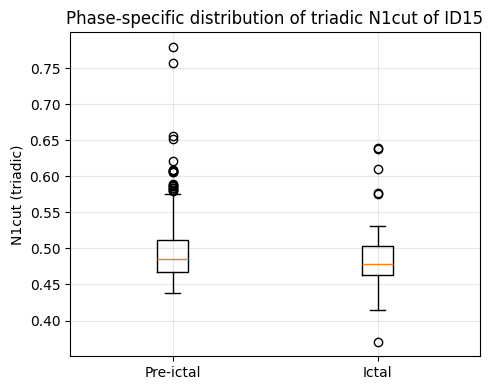

In [ ]:
n1_pre_tri_f = n1_values_tri_f[phase_labels_tri_f == "pre_ictal"]
n1_ict_tri_f = n1_values_tri_f[phase_labels_tri_f == "ictal"]

plt.figure(figsize=(5,4))
plt.boxplot(
    [n1_pre_tri_f, n1_ict_tri_f],
    labels=["Pre-ictal", "Ictal"],
    showfliers=True
)
plt.ylabel("N1cut (triadic)")
plt.title(f"Phase-specific distribution of triadic N1cut of {ID}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("Pre-ictal:", summarize_dist(n1_pre_tri_f))
print("Ictal   :", summarize_dist(n1_ict_tri_f))

Pre-ictal: {'mean': np.float64(0.4932274755007554), 'median': np.float64(0.48550768046448156), 'std': np.float64(0.037057944449638905), 'iqr': np.float64(0.04359549629347298)}
Ictal   : {'mean': np.float64(0.4862371817375568), 'median': np.float64(0.4785441898596295), 'std': np.float64(0.03881636102335381), 'iqr': np.float64(0.04037792440398602)}


In [ ]:
U, p = mannwhitneyu(n1_pre_tri_f, n1_ict_tri_f, alternative="two-sided")#Recurrence quantification analysis of dynamic brain networks

print(f"Mann–Whitney U test: p = {p:.4e}")

Mann–Whitney U test: p = 4.7962e-02


In [ ]:
# mask for entropy (triadic)
window = 10
pre_mask_ent_tri_f = pre_mask_tri_f[window-1:]
ict_mask_ent_tri_f = ict_mask_tri_f[window-1:]

In [ ]:
ent_n1_tri_f = dynamic_entropy(n1_values_tri_f, window=window)
print(f"mean pre_mask_ent: {np.nanmean(ent_n1_tri_f[pre_mask_ent_tri_f])}")
print(f"mean post_mask_ent: {np.nanmean(ent_n1_tri_f[ict_mask_ent_tri_f])}")



mean pre_mask_ent: 1.7144695149363263
mean post_mask_ent: 1.6826783806377


# memory analysis

In [ ]:
r2_lag1_tri_f = lagged_predictability(n1_values_tri_f, lag=1)
r2_lag5_tri_f = lagged_predictability(n1_values_tri_f, lag=5)

print("Triadic N1cut")
print("Lag-1 predictability (R^2):", r2_lag1_tri_f)
print("Lag-5 predictability (R^2):", r2_lag5_tri_f)


Triadic N1cut
Lag-1 predictability (R^2): 0.00025728822574573216
Lag-5 predictability (R^2): 0.00018409912832915922


In [ ]:
r2_pre_tri_f = lagged_predictability(n1_values_tri_f[pre_mask_tri_f], lag=1)
r2_ict_tri_f = lagged_predictability(n1_values_tri_f[ict_mask_tri_f], lag=1)

print("Lag-1 R^2 pre-ictal (triadic):", r2_pre_tri_f)
print("Lag-1 R^2 ictal     (triadic):", r2_ict_tri_f)

Lag-1 R^2 pre-ictal (triadic): 0.0020721710147499415
Lag-1 R^2 ictal     (triadic): 0.020964023694256293


# HDB Scan

In [ ]:
triadic_igraphs_full = []

for t0 in range(0, W - window_size + 1, step):
    t1 = t0 + window_size

    # tradic graph
    G_nx = build_triadic_graph_from_dtct_window(dtct, t0, t1)

    # convertion to igraph because i use it before
    G_ig = ig.Graph.from_networkx(G_nx)

    triadic_igraphs_full.append(G_ig)


In [ ]:
#sepration of windows
pre_graphs_tri  = triadic_igraphs_full[:onset_dyn]
ict_graphs_tri  = triadic_igraphs_full[onset_dyn:]


In [ ]:

#compute the strength, the node is described like [strength_pre(i), strength_ict(i)]
N = triadic_igraphs_full[0].vcount()

strength_pre  = np.zeros(N)
strength_ict  = np.zeros(N)

# PRE
for G in pre_graphs_tri:
    if G.ecount() > 0:
        strength_pre += np.array(G.strength(weights="weight"))
strength_pre /= len(pre_graphs_tri)

# ICTAL
for G in ict_graphs_tri:
    if G.ecount() > 0:
        strength_ict += np.array(G.strength(weights="weight"))
strength_ict /= len(ict_graphs_tri)
#quanto un nodo partecipa a interazioni a 3 nodi,

In [ ]:
X_nodes = np.column_stack([strength_pre, strength_ict])
#normalization

X_nodes = StandardScaler().fit_transform(X_nodes)

#applaied hdbscan
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=2
)

labels_nodes = clusterer.fit_predict(X_nodes)


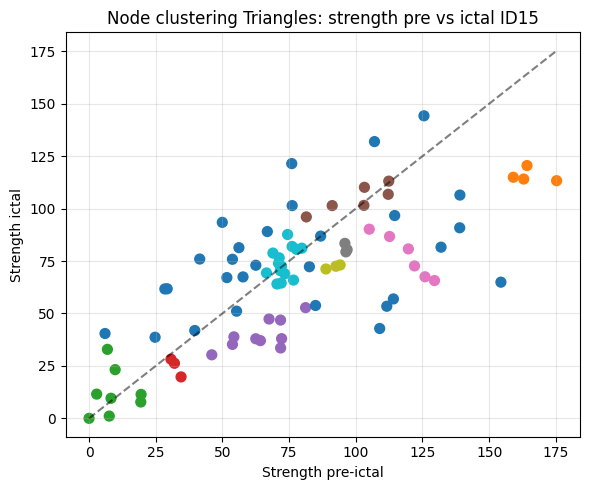

In [ ]:
#visualization
plt.figure(figsize=(6,5))
plt.scatter(
    strength_pre,
    strength_ict,
    c=labels_nodes,
    cmap="tab10",
    s=50
)
plt.plot(
    [strength_pre.min(), strength_pre.max()],
    [strength_pre.min(), strength_pre.max()],
    "--k", alpha=0.5
)
plt.xlabel("Strength pre-ictal")
plt.ylabel("Strength ictal")
plt.title(f"Node clustering Triangles: strength pre vs ictal {ID}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#to remember

# diagonal = stable node
# above = nodes incrsing ictal rules 
# below = nodes lose the ictal rules

# separete cluster 
#-1 = noise= potential critic nodes



In [ ]:


df = pd.DataFrame({
    "node": node_ids,
    "cluster": labels_nodes,
    "strength_pre": strength_pre,
    "strength_ict": strength_ict
})

# ordina per cluster, poi per strength_pre
df_sorted = df.sort_values(["cluster", "strength_pre"])

print(df_sorted)




    node  cluster  strength_pre  strength_ict
43    43       -1      5.994319     40.449774
6      6       -1     24.764915     38.669501
21    21       -1     28.426450     61.699262
2      2       -1     29.297437     61.772227
7      7       -1     39.638732     41.875486
..   ...      ...           ...           ...
50    50        9     71.701243     70.444248
40    40        9     72.041580     64.498537
70    70        9     72.132096     72.535535
85    85        9     73.377326     68.930446
78    78        9     76.657446     65.927335

[86 rows x 4 columns]


In [ ]:

summary = (
    df
    .groupby("cluster")
    .agg(
        n_nodes=("node", "count"),
        mean_pre=("strength_pre", "mean"),
        mean_ict=("strength_ict", "mean"),
        std_pre=("strength_pre", "std"),
        std_ict=("strength_ict", "std")
    )
    .sort_index()
)

print(summary)



         n_nodes    mean_pre    mean_ict    std_pre    std_ict
cluster                                                       
-1            29   78.493249   76.714674  39.486989  26.946880
 0             4  165.373840  115.727478   6.966279   3.276867
 1             8    9.284786   12.190434   7.016283  11.016452
 2             3   32.408805   24.743449   1.924330   4.422538
 3            10   64.533014   39.795293  10.635127   6.996918
 4             6  100.570482  104.855460  12.173274   6.330708
 5             6  119.151453   77.262574   8.976220  10.190301
 6             3   96.323075   81.072687   0.417853   2.113808
 7             3   91.829763   72.296844   2.742563   0.985362
 8             4   77.020907   82.846144   2.276059   3.259499
 9            10   71.414254   70.503545   2.658048   4.982949


In [ ]:
df["delta_strength"] = df["strength_ict"] - df["strength_pre"]
df_outliers = df[df["cluster"] == -1].copy()
df_outliers = df_outliers.sort_values("delta_strength", ascending=False)

print(df_outliers)


    node  cluster  strength_pre  strength_ict  delta_strength
53    53       -1     75.995606    121.463739       45.468134
9      9       -1     49.958574     93.446514       43.487940
20    20       -1     41.489892     75.960710       34.470818
43    43       -1      5.994319     40.449774       34.455455
21    21       -1     28.426450     61.699262       33.272812
2      2       -1     29.297437     61.772227       32.474790
10    10       -1     76.150038    101.431166       25.281129
18    18       -1     56.190926     81.384502       25.193576
56    56       -1    107.014563    131.957948       24.943385
52    52       -1     66.842583     89.063948       22.221364
5      5       -1     53.756404     75.852926       22.096522
11    11       -1    125.558320    144.258093       18.699774
8      8       -1     51.672647     67.112955       15.440308
6      6       -1     24.764915     38.669501       13.904586
12    12       -1     62.528846     72.994650       10.465804
51    51

A2

In [ ]:
# Built the seires of strength for node

N = triadic_igraphs_full[0].vcount()
T = len(triadic_igraphs_full)

strength_dyn = np.zeros((N, T))

for t, G in enumerate(triadic_igraphs_full):
    if G.ecount() > 0:
        strength_dyn[:, t] = np.array(G.strength(weights="weight"))
    else:
        strength_dyn[:, t] = 0.0

In [ ]:
# feature for node
mean_strength = strength_dyn.mean(axis=1)
std_strength  = strength_dyn.std(axis=1)

X_nodes2 = np.column_stack([mean_strength, std_strength])
# normalization 
X_nodes2 = StandardScaler().fit_transform(X_nodes2)
# applaied HDBSCAN
clusterer2 = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=2
)

labels_nodes2 = clusterer2.fit_predict(X_nodes2)

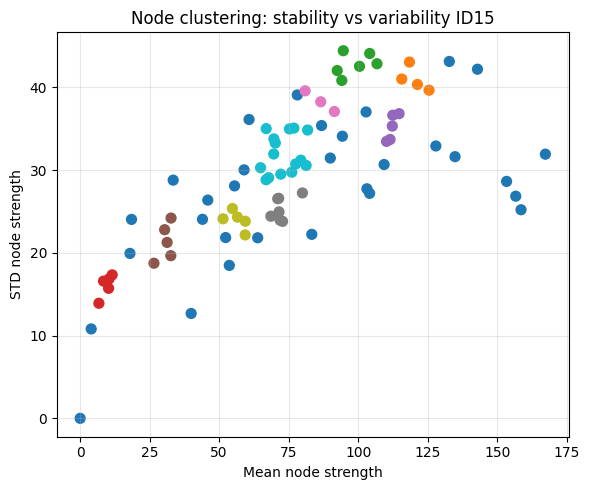

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(
    mean_strength,
    std_strength,
    c=labels_nodes2,
    cmap="tab10",
    s=50
)
plt.xlabel("Mean node strength")
plt.ylabel("STD node strength")
plt.title(f"Node clustering: stability vs variability {ID}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
df2 = pd.DataFrame({
    "node": node_ids,
    "cluster": labels_nodes2,
    "mean_strength": mean_strength,
    "std_strength": std_strength
})

summary2 = (
    df2
    .groupby("cluster")
    .agg(
        n_nodes=("node", "count"),
        mean_mean=("mean_strength", "mean"),
        mean_std=("std_strength", "mean")
    )
    .sort_index()
)

print(summary2)

# to remember
# mean_strength H std_strength L, stable hub
# mean_strength H std_strength H, dyanmic hub
# mean_strength L std_strength L, stable periferic 
# mean_strength L std_strength H, errors nodes (not stable in the time)
# mean_strength extrene, std_strength extreme = outlier


         n_nodes   mean_mean   mean_std
cluster                                
-1            27   73.030739  27.333539
 0             4  150.887362  28.073949
 1             4  120.245519  41.011463
 2             6   98.779883  42.791052
 3             5    9.461783  16.076790
 4             5  112.233635  35.185317
 5             5   30.703590  21.330454
 6             3   86.307325  38.300282
 7             7   72.478669  25.351784
 8             5   56.309663  23.950655
 9             8   73.264688  29.991513
 10            7   72.919493  34.122565


In [ ]:

df2["cv_strength"] = df2["std_strength"] / df2["mean_strength"]
df2_outliers = df2[df2["cluster"] == -1].copy()

# reorder for variability
df2_outliers = df2_outliers.sort_values("std_strength", ascending=False)




print(
    df2_outliers[
        ["node", "mean_strength", "std_strength", "cv_strength"]
    ]
)


    node  mean_strength  std_strength  cv_strength
61    61     132.794314     43.123695     0.324741
33    33     142.933113     42.188124     0.295160
47    47      78.104767     39.076448     0.500308
1      1     102.852531     37.023876     0.359970
75    75      60.756538     36.111930     0.594371
16    16      86.835021     35.377476     0.407410
65    65      94.320670     34.092178     0.361450
11    11     127.955727     32.910393     0.257201
60    60     167.347616     31.919491     0.190738
23    23      89.982876     31.450544     0.349517
22    22     109.338466     30.670270     0.280508
51    51      58.968361     30.022355     0.509126
2      2      33.460871     28.782215     0.860175
9      9      55.533951     28.088423     0.505788
67    67     103.146351     27.736461     0.268904
25    25     104.126737     27.184917     0.261075
20    20      45.909227     26.370566     0.574407
59    59      44.000761     24.049715     0.546575
76    76      18.476076     24.

A3 

In [ ]:
# filder function
def fiedler_from_igraph(G):
    n = G.vcount()
    if G.ecount() == 0:
        return np.full(n, np.nan)

    W = np.zeros((n, n))
    edges = G.get_edgelist()
    weights = np.array(G.es["weight"], dtype=float)

    for (u, v), w in zip(edges, weights):
        W[u, v] += w
        W[v, u] += w

    d = W.sum(axis=1)
    D = np.diag(d)
    L = D - W

    evals, evecs = np.linalg.eigh(L)
    if len(evals) < 2:
        return np.full(n, np.nan)

    return evecs[:, 1]   


In [ ]:
# each node is desbribed from [Fiedler_pre(i), Fiedler_ict(i)]
pre_graphs = triadic_igraphs_full[:onset_dyn]
ict_graphs = triadic_igraphs_full[onset_dyn:]

N = triadic_igraphs_full[0].vcount()

fiedler_pre = np.zeros(N)
fiedler_ict = np.zeros(N)

# PRE
cnt = 0
for G in pre_graphs:
    f = fiedler_from_igraph(G)
    if not np.all(np.isnan(f)):
        fiedler_pre += f
        cnt += 1
fiedler_pre /= cnt

# ICTAL
cnt = 0
for G in ict_graphs:
    f = fiedler_from_igraph(G)
    if not np.all(np.isnan(f)):
        fiedler_ict += f
        cnt += 1
fiedler_ict /= cnt


In [ ]:
X_nodes3 = np.column_stack([fiedler_pre, fiedler_ict])

X_nodes3 = StandardScaler().fit_transform(X_nodes3)

clusterer3 = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=2
)

labels_nodes3 = clusterer3.fit_predict(X_nodes3)


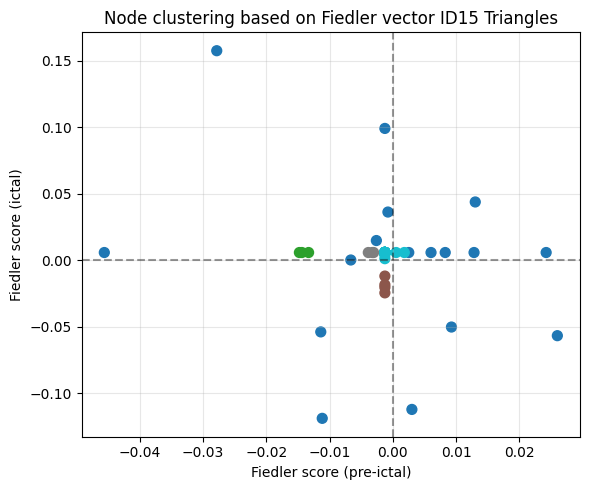

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(
    fiedler_pre,
    fiedler_ict,
    c=labels_nodes3,
    cmap="tab10",
    s=50
)

plt.axhline(0, ls="--", c="k", alpha=0.4)
plt.axvline(0, ls="--", c="k", alpha=0.4)

plt.xlabel("Fiedler score (pre-ictal)")
plt.ylabel("Fiedler score (ictal)")
plt.title(f"Node clustering based on Fiedler vector {ID} Triangles")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:

df3 = pd.DataFrame({
    "node": node_ids,
    "cluster": labels_nodes3,
    "fiedler_pre": fiedler_pre,
    "fiedler_ict": fiedler_ict
})

df3["delta_fiedler"] = df3["fiedler_ict"] - df3["fiedler_pre"]

summary3 = (
    df3
    .groupby("cluster")
    .agg(
        n_nodes=("node", "count"),
        mean_pre=("fiedler_pre", "mean"),
        mean_ict=("fiedler_ict", "mean"),
        mean_delta=("delta_fiedler", "mean")
    )
    .sort_index()
)

print(summary3)
# delta pos = dirver (more important)
# delta neg = other side of the cut 

         n_nodes  mean_pre  mean_ict  mean_delta
cluster                                         
-1            17 -0.000123 -0.000450   -0.000327
 0             3 -0.014159  0.005670    0.019828
 1             4 -0.001260 -0.018942   -0.017682
 2             3 -0.003387  0.005670    0.009057
 3            59 -0.001178  0.005546    0.006723


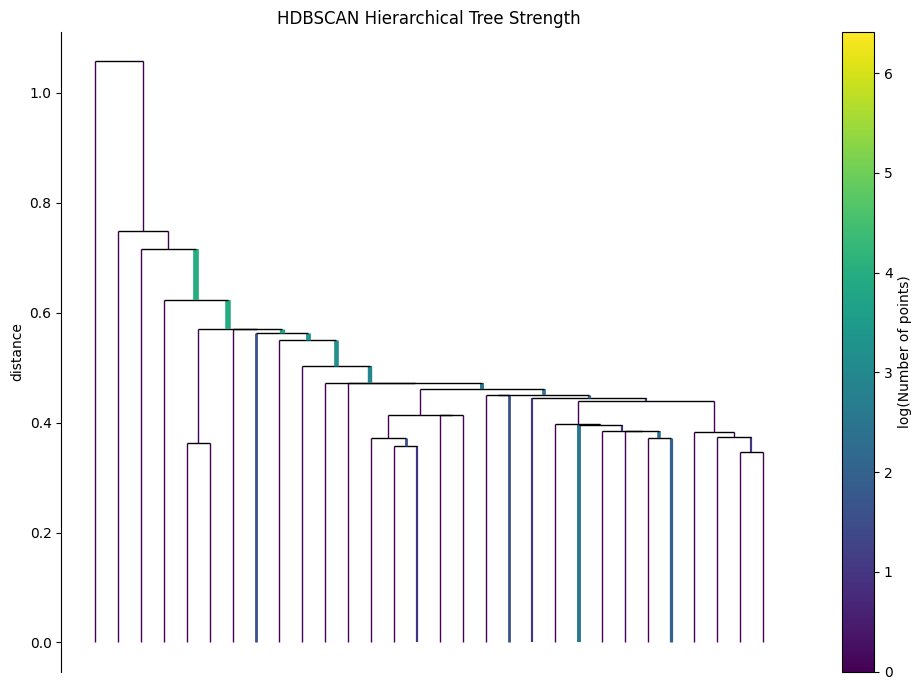

In [ ]:
plt.figure(figsize=(10,7))

clusterer.single_linkage_tree_.plot(
    truncate_mode='lastp',
    p=30   
)

plt.title("HDBSCAN Hierarchical Tree Strength")
plt.tight_layout()
plt.show()


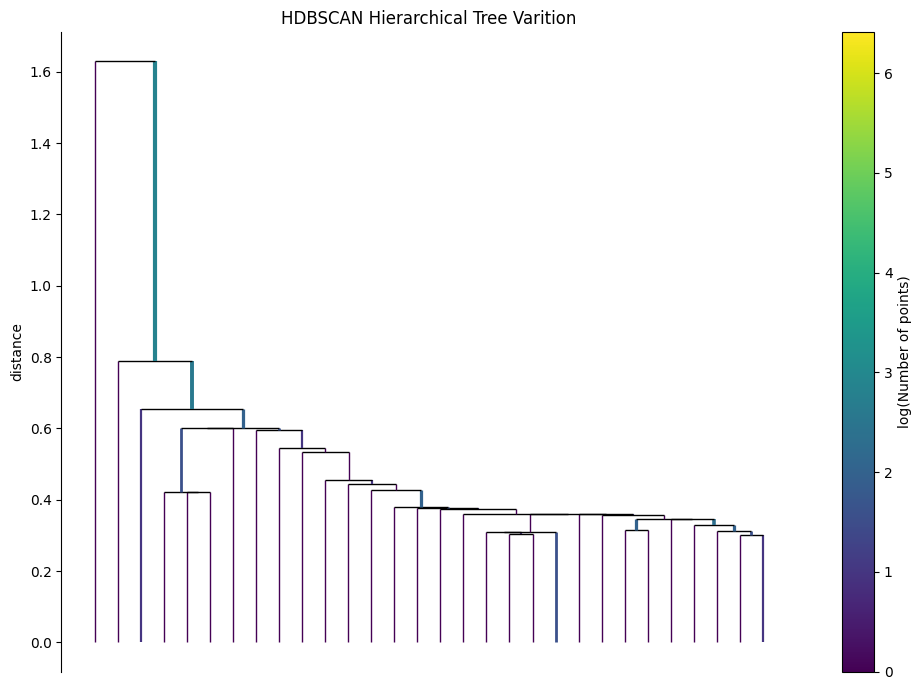

In [ ]:
plt.figure(figsize=(10,7))

clusterer2.single_linkage_tree_.plot(
    truncate_mode='lastp',
    p=30   
)

plt.title("HDBSCAN Hierarchical Tree Varition")
plt.tight_layout()
plt.show()


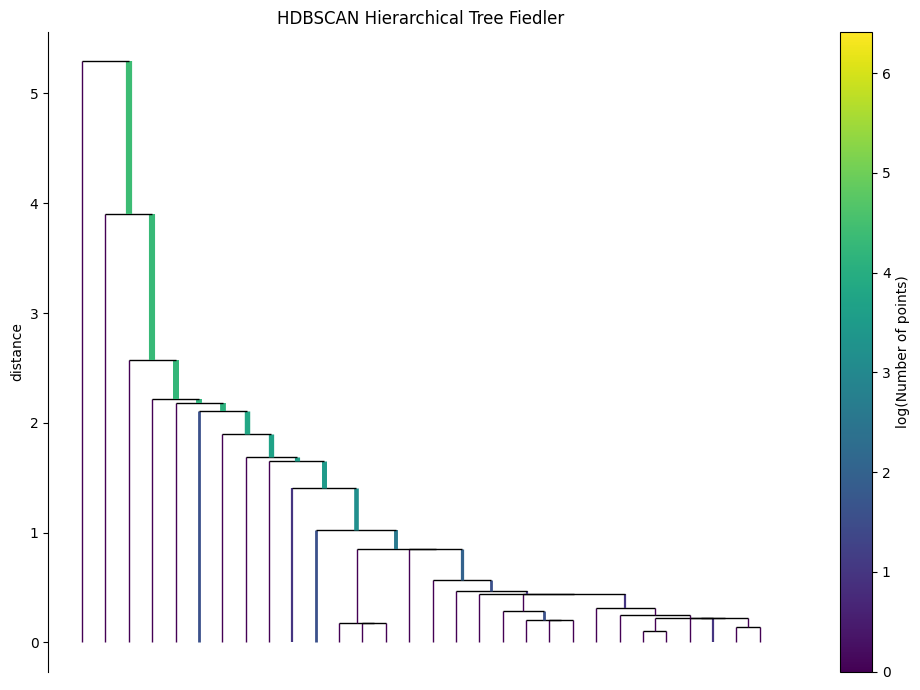

In [ ]:
plt.figure(figsize=(10,7))

clusterer3.single_linkage_tree_.plot(
    truncate_mode='lastp',
    p=30   
)

plt.title("HDBSCAN Hierarchical Tree Fiedler")
plt.tight_layout()
plt.show()


# overlapping

In [ ]:
#chaningn of the strength only the top
thr1 = np.percentile(np.abs(df["delta_strength"]), 80)
nodes_A1 = set(df.loc[np.abs(df["delta_strength"]) > thr1, "node"])


In [ ]:
#instable nodes only th top
thr2 = np.percentile(df2["std_strength"], 80)
nodes_A2 = set(df2.loc[df2["std_strength"] > thr2, "node"])


In [ ]:
#relevant spectral nodes, only the top
thr3 = np.percentile(np.abs(df3["delta_fiedler"]), 80)
nodes_A3 = set(df3.loc[np.abs(df3["delta_fiedler"]) > thr3, "node"])


In [ ]:
#overlapping
A12 = nodes_A1 & nodes_A2
A13 = nodes_A1 & nodes_A3
A23 = nodes_A2 & nodes_A3
A123 = nodes_A1 & nodes_A2 & nodes_A3
print("A1 (strength change):", len(nodes_A1))
print("A2 (instability):", len(nodes_A2))
print("A3 (spectral role):", len(nodes_A3))



A1 (strength change): 17
A2 (instability): 17
A3 (spectral role): 17


In [ ]:
print("A1 ∩ A2:", len(A12))
print("A1 ∩ A3:", len(A13))
print("A2 ∩ A3:", len(A23))
print("A1 ∩ A2 ∩ A3:", len(A123))


A1 ∩ A2: 9
A1 ∩ A3: 0
A2 ∩ A3: 1
A1 ∩ A2 ∩ A3: 0


In [ ]:
core_nodes = sorted(A123)
print("CORE NODES: The only nodes that change strength (A1), instable during the time (A2) and drive the spectral bipartition (A3), for triangles")
print(core_nodes)


CORE NODES: The only nodes that change strength (A1), instable during the time (A2) and drive the spectral bipartition (A3), for triangles
[]
